<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/DutchLargeCaps_Entry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade yfinance
!pip install  --upgrade pandas_ta
!pip install ta pandas_ta
!pip install scipy==1.16.2
!pip install hurst -q

  Using cached ta-0.11.0-py3-none-any.whl
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 26.3 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


## Install libraries

In [2]:
import yfinance as yf
print(yf.__version__)
import pandas as pd
import numpy as np
from datetime import datetime
import time
import ta
import random
import requests
from datetime import datetime, timedelta
from scipy.stats import linregress
from transformers import pipeline
import matplotlib.pyplot as plt
from hurst import compute_Hc

from dataclasses import dataclass, field
from typing import Optional
import warnings
warnings.filterwarnings("ignore")
# ensure reproducibility
random.seed(42)
print("Libraries Installed!")

1.4.1
Libraries Installed!


## What is the market doing?

Calculating rolling Hurst...

Finished! Valid Hurst values: 1100/1100

Last 10 Days - Hurst, Alpha, K_Alpha, Regime & Adaptive EMAs
             Hurst   Alpha  K_Alpha                        Regime  \
2026-06-05  0.4850  1.0000   0.5000     Random Walk — Reduce Size   
2026-06-08  0.4935  1.0000   0.5000     Random Walk — Reduce Size   
2026-06-09  0.4793  1.0000   0.5000     Random Walk — Reduce Size   
2026-06-10  0.4926  1.0000   0.5000     Random Walk — Reduce Size   
2026-06-11  0.4825  1.0000   0.5000     Random Walk — Reduce Size   
2026-06-12  0.4847  1.0000   0.5000     Random Walk — Reduce Size   
2026-06-15  0.5020  0.9959   0.5061     Random Walk — Reduce Size   
2026-06-16  0.5085  0.9830   0.5255     Random Walk — Reduce Size   
2026-06-17  0.5243  0.9514   0.5729     Random Walk — Reduce Size   
2026-06-18  0.5540  0.8921   0.6619  Trending — Momentum Favoured   

            Fast_EMA_Len  Slow_EMA_Len  
2026-06-05             5            10  
2026-06-08             5  

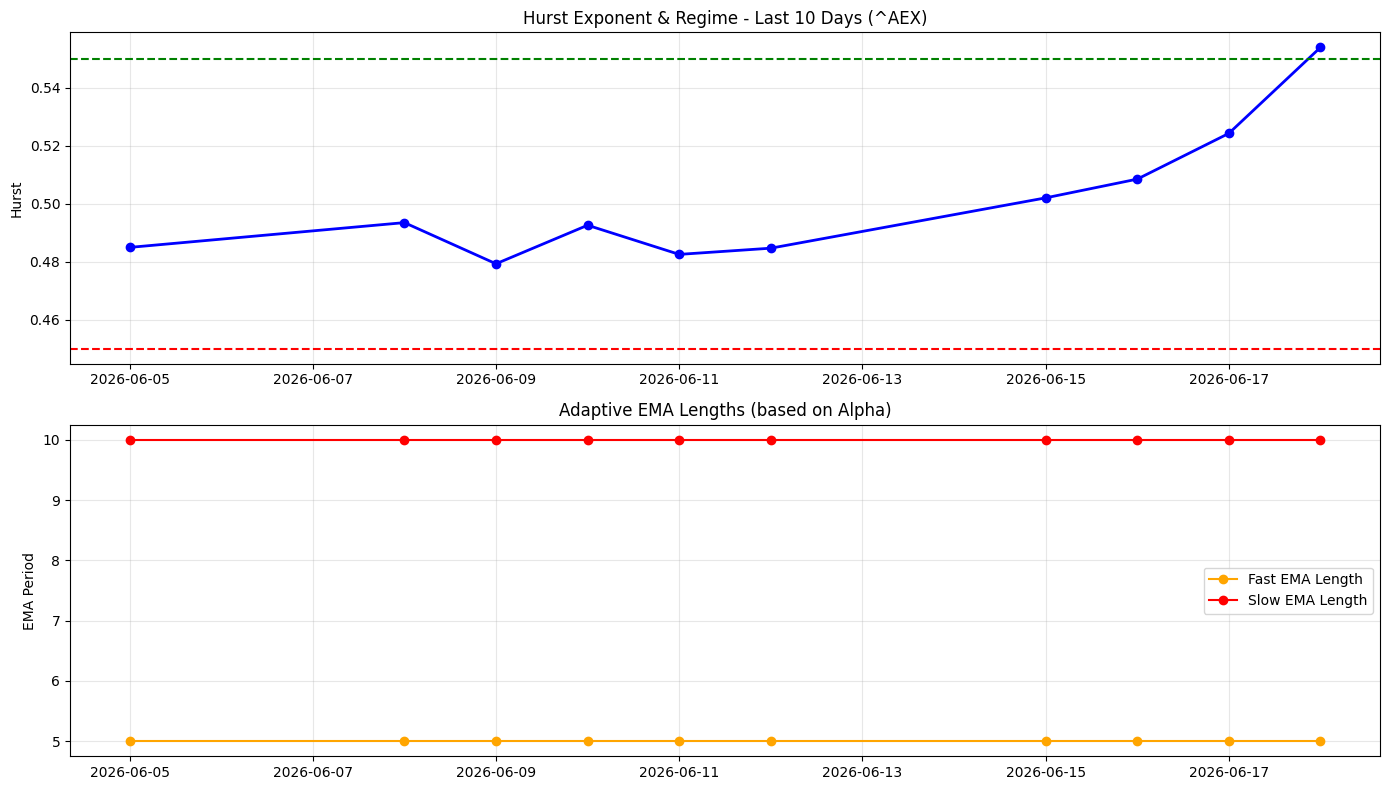

In [5]:
# ^FTSE
def get_prices(ticker="^AEX", period="5y"):
    df = yf.download(ticker, period=period, progress=False, auto_adjust=True)
    return df["Close"].dropna()

def hurst_exponent(ts):
    ts = np.asarray(ts, dtype=float)
    if len(ts) < 100:
        return np.nan
    try:
        H, _, _ = compute_Hc(ts, kind="price", simplified=True)
        return H
    except:
        return np.nan

def get_regime(h):
    if np.isnan(h):
        return "Unknown"
    elif h > 0.55:
        return "Trending — Momentum Favoured"
    elif h < 0.45:
        return "Mean Reverting — Counter-trend Favoured"
    else:
        return "Random Walk — Reduce Size"

# ====================== NEW FUNCTIONS ======================
def ema_length(alpha, n_min, n_max, k=2):
    """Convert market memory alpha into EMA length"""
    return n_min + (n_max - n_min) * (1 - alpha) ** k

def adaptive_ema_lengths(alpha):
    """Returns fast and slow EMA lengths"""
    fast = ema_length(alpha, n_min=5, n_max=20, k=2)
    slow = ema_length(alpha, n_min=10, n_max=50, k=2)
    return int(round(fast)), int(round(slow))

# ====================== ROLLING HURST ======================
def rolling_hurst(prices, window=180):
    hurst_vals = []
    dates = []
    valid = 0

    print("Calculating rolling Hurst...")

    for i in range(window, len(prices)):
        chunk = prices.iloc[i-window:i].values
        h = hurst_exponent(chunk)
        hurst_vals.append(h)
        dates.append(prices.index[i])

        if not np.isnan(h):
            valid += 1

        if i % 100 == 0:
            print(f"Progress: {i}/{len(prices)} | Valid: {valid}", end="\r")

    H = pd.Series(hurst_vals, index=dates, name="Hurst")
    print(f"\nFinished! Valid Hurst values: {valid}/{len(H)}")
    return H


# ====================== RUN ======================

ticker = "^AEX"
prices = get_prices(ticker)

H = rolling_hurst(prices, window=180)
alpha = np.clip(2 - 2 * H, 0, 1)
k_alpha = 0.5 + 1.5*(1-alpha)

# Create main dataframe
df = pd.DataFrame({
    "Hurst": H,
    "Alpha": alpha,
    "K_Alpha": k_alpha,
    "Regime": H.apply(get_regime)
})

# Add Adaptive EMA Lengths
df['Fast_EMA_Len'], df['Slow_EMA_Len'] = zip(*df['Alpha'].apply(adaptive_ema_lengths))

# Calculate actual EMAs using adaptive lengths (using latest Alpha for simplicity)
latest_alpha = df['Alpha'].iloc[-1]
#latest_Kalpha = df['K_Alpha'].iloc[-1]
#fast_len, slow_len = adaptive_ema_lengths(latest_alpha)

latest_Kalpha = 1
fast_len, slow_len = 8, 15

df['Fast_EMA'] = prices.ewm(span=fast_len, adjust=False).mean()
df['Slow_EMA'] = prices.ewm(span=slow_len, adjust=False).mean()

# Last 10 days
last10 = df.dropna().tail(10)

print("\n" + "="*100)
print("Last 10 Days - Hurst, Alpha, K_Alpha, Regime & Adaptive EMAs")
print(last10[['Hurst', 'Alpha','K_Alpha', 'Regime', 'Fast_EMA_Len', 'Slow_EMA_Len']].round(4))

print(f"\nCurrent Adaptive EMAs (based on latest Alpha):")
print(f"Fast EMA Length : {fast_len}")
print(f"Slow EMA Length : {slow_len}")
print(f"Current Market Memory : {latest_alpha}")
print(f"Current k Alpha : {latest_Kalpha}")

# Plot
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(last10.index, last10["Hurst"], marker='o', color='blue', linewidth=2)
plt.axhline(0.55, color='green', linestyle='--')
plt.axhline(0.45, color='red', linestyle='--')
plt.title(f"Hurst Exponent & Regime - Last 10 Days ({ticker})")
plt.ylabel("Hurst")
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(last10.index, last10["Fast_EMA_Len"], marker='o', label='Fast EMA Length', color='orange')
plt.plot(last10.index, last10["Slow_EMA_Len"], marker='o', label='Slow EMA Length', color='red')
plt.title("Adaptive EMA Lengths (based on Alpha)")
plt.ylabel("EMA Period")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
today = datetime.today()
start_of_year = today.replace(month=1, day=1)

# First day of this month
first_day_month = today.replace(day=1)

# First day of this week (Monday as weekday 0)
first_day_week = today - timedelta(days=today.weekday())
print("First day of year:", start_of_year)

print("\nFirst day of this month:", first_day_month)
print("\nFirst day of this week:", first_day_week)

def most_recent_quarter_start(today=None):
    if today is None:
        today = pd.Timestamp.today().normalize()
    year = today.year
    month = today.month

    # Determine quarter start months: Jan, Apr, Jul, Oct
    if month >= 10:
        q_start = pd.Timestamp(year, 10, 1)
    elif month >= 7:
        q_start = pd.Timestamp(year, 7, 1)
    elif month >= 4:
        q_start = pd.Timestamp(year, 4, 1)
    else:
        q_start = pd.Timestamp(year, 1, 1)

    return q_start

# Example usage
print("Today:", pd.Timestamp.today().normalize())
print("Most recent quarter start:", most_recent_quarter_start())


First day of year: 2026-01-01 22:21:18.947462

First day of this month: 2026-06-01 22:21:18.947462

First day of this week: 2026-06-15 22:21:18.947462
Today: 2026-06-19 00:00:00
Most recent quarter start: 2026-04-01 00:00:00


In [13]:
# List of ETFs to analyze
df_raw = pd.read_csv('etf_list.csv')
df_raw =df_raw.drop_duplicates(subset=['Asset'])
df_raw = df_raw[df_raw['Type'].isin(['AS'])]
recent_quarter = most_recent_quarter_start()
etfs = df_raw['Asset'].to_list()
print(etfs)

print(len(etfs))

['MP1.AX', 'SGM.AX', 'JHX.AX', '360.AX', 'PMV.AX', 'WEB.AX', 'SFR.AX', 'RWC.AX', 'BSL.AX', 'TWE.AX', 'MIN.AX', 'VGN.AX', 'WES.AX', 'REH.AX', 'FLT.AX', 'BHP.AX', 'QAN.AX', 'PLS.AX', 'XYZ.AX', 'TNE.AX', 'CDA.AX', 'VNT.AX', 'LNW.AX', 'DNL.AX', 'BRG.AX', 'WOW.AX', 'WOR.AX', 'DBI.AX', 'IGO.AX', 'COL.AX', 'SNL.AX', 'ALL.AX', 'MTS.AX', 'CAR.AX', 'GGP.AX', 'AIZ.AX', 'GYG.AX', 'ALX.AX', 'JBH.AX', 'EMR.AX', 'RIO.AX', 'VAU.AX', 'ALQ.AX', 'DOW.AX', 'AMC.AX']
45


## Filter for liquidity

In [14]:
# Filter ETFs or stocks for liquidity
def filter_by_liquidity(etf_df, ticker_col="Asset", min_dollar_vol=10e6, lookback_days=30):
    liquid_etfs = []

    for ticker in etf_df[ticker_col]:
        try:
            # Fetch daily historical data
            data = yf.download(ticker, period=f"{lookback_days*2}d", interval="1d", auto_adjust=True)

            if data.empty:
                continue

            # Calculate dollar volume (Close × Volume)
            data["dollar_volume"] = data["Close"] * data["Volume"]

            # Calculate rolling average over lookback_days
            avg_dollar_volume = data["dollar_volume"].rolling(window=lookback_days).mean().iloc[-1]

            # Check liquidity condition
            if avg_dollar_volume >= min_dollar_vol:
                liquid_etfs.append(ticker)

        except Exception as e:
            print(f"Error fetching {ticker}: {e}")

    # Return filtered DataFrame
    return etf_df[etf_df[ticker_col].isin(liquid_etfs)]

# Example usage
df = pd.DataFrame({"Assets": etfs})
liquid_df = filter_by_liquidity(df, ticker_col="Assets")
df_o = df_raw[df_raw['Asset'].isin(liquid_df['Assets'])]
etfs2 = df_o['Asset'].to_list()
etfs = list(dict.fromkeys(etfs2))
print("")
print(etfs)
print(len(etfs))



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********


['MP1.AX', 'SGM.AX', 'JHX.AX', '360.AX', 'WEB.AX', 'SFR.AX', 'RWC.AX', 'BSL.AX', 'TWE.AX', 'MIN.AX', 'WES.AX', 'FLT.AX', 'BHP.AX', 'QAN.AX', 'PLS.AX', 'XYZ.AX', 'TNE.AX', 'CDA.AX', 'VNT.AX', 'LNW.AX', 'DNL.AX', 'BRG.AX', 'WOW.AX', 'WOR.AX', 'IGO.AX', 'COL.AX', 'ALL.AX', 'MTS.AX', 'CAR.AX', 'GGP.AX', 'GYG.AX', 'ALX.AX', 'JBH.AX', 'EMR.AX', 'RIO.AX', 'VAU.AX', 'ALQ.AX', 'AMC.AX']
38


# Classify Sector Stages

In [15]:
def weinstein_stage(df, sma_window=30,smaSlope_window=5):
    """Determine Weinstein stage using 30-week SMA and its slope."""
     # Handle MultiIndex columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df["SMA"] = df["Close"].rolling(window=sma_window).mean()
    df["10_SMA"] = df["Close"].rolling(window=10).mean()

    # Compute linear regression slope on last N SMA points
    if len(df.dropna()) < sma_window:
        return None  # not enough data

    slope, _, _, _, _ = linregress(range(smaSlope_window), df["SMA"].tail(smaSlope_window))
    #slope_short, _, _, _, _ = linregress(range(smaSlope_window), df["10_SMA"].tail(smaSlope_window))

    latest_price = df["Close"].iloc[-1]
    latest_sma   = df["SMA"].iloc[-1]
    latest_10sma = df["10_SMA"].iloc[-1]

    # Determine stage
    if (latest_price > latest_sma) and (slope > 0) : #and (latest_price > latest_10sma) and (latest_10sma > latest_sma):
        stage = "Stage 2 (Advancing)"
    elif latest_price < latest_sma and slope < 0:
        stage = "Stage 4 (Declining)"
    elif np.abs(slope) <= 0.001:
        stage = "Stage 1 (Basing)"
    else:
        stage = "Stage 3 (Topping)"

    return stage, slope, latest_price, latest_sma, latest_10sma


In [30]:
results = []
for etf in etfs:
    df = yf.download(etf, period="3y", interval="1wk", auto_adjust=True)
    stage_info = weinstein_stage(df)
    if stage_info:
        stage, slope, price, sma,sma_10 = stage_info
        results.append({
            "ETF": etf,
            "Stage": stage,
            "SMA_Slope": slope,
            "Latest_Price": price,
            "30W_SMA": sma,
            "10W_SMA": sma_10
        })

stages_df = pd.DataFrame(results).sort_values(by="SMA_Slope", ascending=False)

advancing_stocks= stages_df[stages_df["Stage"] .isin(["Stage 2 (Advancing)"]) ]
advancing_stocks.reset_index(drop=True, inplace=True)

# List of ETFs to analyze
df_1 = df_o[df_o['Asset'].isin(advancing_stocks['ETF'])]
etfs2 = df_1['Asset'].to_list()
etfs_clean = list(dict.fromkeys(etfs2))
print()
print(len(etfs_clean))


[*********************100%***********************]  1 of 1 completed


1


# Brian Shannon daily timeframe stage classification

In [31]:
@dataclass
class ClassifierConfig:
    short_ma:       int   = 20
    medium_ma:      int   = 50
    long_ma:        int   = 200
    atr_period:     int   = 14
    slope_period:   int   = 10       # wider slope window = less noise
    rs_period:      int   = 63       # 3-month RS — more meaningful
    volume_period:  int   = 50       # 50-bar vol average — institutional grade
    pivot_lookback: int   = 10       # wider pivot = fewer false swings

    # ── Strictness preset
    # "strict"   — original settings, high conviction only
    # "balanced" — recommended, catches more valid setups
    # "relaxed"  — widest net, use with additional filters downstream
    strictness: str = "balanced"

    def __post_init__(self):
        """Auto-configure thresholds based on strictness level."""

        presets = {

            "strict": {
                # Stage 2
                "stage2_min_score":       7,
                "stage2_ma50_slope_min":  0.0,
                "stage2_ma200_slope_min": 0.0,    # all three MAs must rise
                # Stage 1
                "stage1_slope_max":       0.03,
                "stage1_atr_max":         0.04,
                "stage1_ma50_proximity":  0.07,
                # Stage 4
                "stage4_rs_penalty":     -0.05,   # must underperform by 5%
            },

            "balanced": {
                # Stage 2
                "stage2_min_score":       6,       # down from 7
                "stage2_ma50_slope_min":  0.0,
                "stage2_ma200_slope_min": -0.01,   # 200 MA can be very slightly negative
                                                    # catches early Stage 2 before 200 MA turns
                # Stage 1
                "stage1_slope_max":       0.04,    # slightly looser
                "stage1_atr_max":         0.05,
                "stage1_ma50_proximity":  0.08,
                # Stage 4
                "stage4_rs_penalty":     -0.02,    # less strict RS requirement
            },

            "relaxed": {
                # Stage 2
                "stage2_min_score":       5,       # catches more early setups
                "stage2_ma50_slope_min":  0.0,
                "stage2_ma200_slope_min": -0.03,   # 200 MA can still be declining
                                                    # valid for early Stage 2 breakouts
                # Stage 1
                "stage1_slope_max":       0.06,
                "stage1_atr_max":         0.06,
                "stage1_ma50_proximity":  0.10,
                # Stage 4
                "stage4_rs_penalty":      0.0,     # any negative RS qualifies
            },
        }

        if self.strictness not in presets:
            raise ValueError(
                f"strictness must be 'strict', 'balanced' or 'relaxed' "
                f"— got '{self.strictness}'"
            )

        preset = presets[self.strictness]

        # Stage 2
        self.stage2_min_score       = preset["stage2_min_score"]
        self.stage2_ma50_slope_min  = preset["stage2_ma50_slope_min"]
        self.stage2_ma200_slope_min = preset["stage2_ma200_slope_min"]

        # Stage 1
        self.stage1_slope_max       = preset["stage1_slope_max"]
        self.stage1_atr_max         = preset["stage1_atr_max"]
        self.stage1_ma50_proximity  = preset["stage1_ma50_proximity"]

        # Stage 4
        self.stage4_rs_penalty      = preset["stage4_rs_penalty"]

# =============================================================
# CLASSIFIER
# =============================================================

class BrianShannonAuctionClassifier:
    """
    Improved Brian Shannon Auction Market Stage Classifier.

    Improvements over original:
    ----------------------------
    1.  Wider slope window (10 bars) — reduces slope noise
    2.  3-month RS period — more institutionally meaningful
    3.  MA200 slope condition added to Stage 2 — prevents false markups
    4.  Stage 1 uses tighter slope + ATR thresholds
    5.  Stage 4 requires negative RS — removes weak/sideways false declines
    6.  Weighted trend score — not all signals are equal
    7.  Stage confidence score added — tells you how strong each call is
    8.  Stage transition detection — flags when stage is changing
    9.  RS percentile rank — tells you where RS stands vs its own history
    10. Multi-stock scanner built in — scan a list and get ranked results
    """

    def __init__(self, config: Optional[ClassifierConfig] = None):
        self.config = config or ClassifierConfig()

    # =========================================================
    # PUBLIC — SINGLE STOCK
    # =========================================================
    def classify(self, df: pd.DataFrame) -> pd.DataFrame:

        df = df.copy()

        self._moving_averages(df)
        self._atr(df)
        self._relative_strength(df)
        self._volume_analysis(df)
        self._trend_structure(df)
        self._trend_score(df)
        self._classify_stages(df)
        self._stage_confidence(df)
        self._stage_transitions(df)

        return df

    # =========================================================
    # PUBLIC — MULTI STOCK SCANNER
    # =========================================================
    def scan(
        self,
        tickers:    list,
        benchmark:  str  = "^AEX",
        start:      str  = "2022-01-01",
        min_score:  int  = 0,
        stage_filter: Optional[int] = None
    ) -> pd.DataFrame:
        """
        Scan a list of tickers and return a ranked summary DataFrame.

        Parameters
        ----------
        tickers      : list of ticker symbols
        benchmark    : benchmark ticker for RS (default SPY)
        start        : start date for data download
        min_score    : minimum trend_score to include in results
        stage_filter : filter by stage number (1/2/3/4) or None for all

        Returns
        -------
        pd.DataFrame sorted by trend_score descending
        """

        print(f"\nDownloading benchmark ({benchmark})...")
        spy_data = yf.download(benchmark, start=start, progress=False)

        results = []

        for i, ticker in enumerate(tickers, 1):

            print(f"[{i}/{len(tickers)}] Processing {ticker}...", end=" ")

            try:

                data = yf.download(ticker, start=start, progress=False)

                if data.empty or len(data) < self.config.long_ma + 10:
                    print("SKIP — insufficient data")
                    continue

                # flatten multi-level columns if present
                if isinstance(data.columns, pd.MultiIndex):
                    data.columns = data.columns.get_level_values(0)

                data["benchmark_close"] = spy_data["Close"].reindex(
                    data.index
                ).ffill()

                classified = self.classify(data)
                latest     = classified.iloc[-1]
                prev       = classified.iloc[-2]

                results.append({
                    "Ticker":        ticker,
                    "Close":         round(latest["Close"], 2),
                    "Stage":         int(latest["stage_number"])
                                     if not np.isnan(latest["stage_number"])
                                     else 0,
                    "Stage Label":   latest["stage"],
                    "Trend Score":   int(latest["trend_score"]),
                    "Confidence":    round(latest["stage_confidence"], 1),
                    "RS (3M)":       round(latest["rs"] * 100, 2)
                                     if not np.isnan(latest["rs"]) else np.nan,
                    "RS Percentile": round(latest["rs_percentile"], 1)
                                     if not np.isnan(latest["rs_percentile"])
                                     else np.nan,
                    "Transitioning": latest["stage_transitioning"],
                    "MA20":          round(latest["ma20"], 2),
                    "MA50":          round(latest["ma50"], 2),
                    "MA200":         round(latest["ma200"], 2),
                    "ATR%":          round(latest["atr_pct"] * 100, 2),
                    "Vol Ratio":     round(latest["volume_ratio"], 2),
                    "Accum Days":    int(
                                         classified["accumulation_day"]
                                         .tail(10).sum()
                                     ),
                    "Dist Days":     int(
                                         classified["distribution_day"]
                                         .tail(10).sum()
                                     ),
                })

                print(f"{latest['stage']} | Score: {int(latest['trend_score'])} | Conf: {round(latest['stage_confidence'], 1)}%")

            except Exception as e:
                print(f"ERROR — {e}")
                continue

        if not results:
            print("No results returned.")
            return pd.DataFrame()

        df_results = pd.DataFrame(results)

        # apply filters
        if min_score > 0:
            df_results = df_results[df_results["Trend Score"] >= min_score]

        if stage_filter is not None:
            df_results = df_results[df_results["Stage"] == stage_filter]

        # sort by trend score then confidence
        df_results = df_results.sort_values(
            ["Trend Score", "Confidence"],
            ascending=False
        ).reset_index(drop=True)

        return df_results

    # =========================================================
    # LATEST STAGE — SINGLE STOCK
    # =========================================================
    def latest_stage(self, df: pd.DataFrame) -> dict:

        latest = df.iloc[-1]

        return {
            "date":          latest.name,
            "close":         round(latest["Close"], 2),
            "stage":         latest["stage"],
            "stage_number":  latest["stage_number"],
            "trend_score":   int(latest["trend_score"]),
            "confidence":    round(latest["stage_confidence"], 1),
            "rs_3m":         round(latest["rs"] * 100, 2)
                             if not np.isnan(latest["rs"]) else None,
            "rs_percentile": round(latest["rs_percentile"], 1)
                             if not np.isnan(latest["rs_percentile"]) else None,
            "transitioning": latest["stage_transitioning"],
        }

    # =========================================================
    # MOVING AVERAGES — wider slope window
    # =========================================================
    def _moving_averages(self, df):

        c = self.config

        df["ma20"]  = df["Close"].rolling(c.short_ma).mean()
        df["ma50"]  = df["Close"].rolling(c.medium_ma).mean()
        df["ma200"] = df["Close"].rolling(c.long_ma).mean()

        for ma in ["ma20", "ma50", "ma200"]:
            # normalize slope as % per bar — comparable across price levels
            df[f"{ma}_slope"] = (
                (df[ma] - df[ma].shift(c.slope_period))
                / df[ma].shift(c.slope_period)
            ) / c.slope_period * 100

    # =========================================================
    # ATR
    # =========================================================
    def _atr(self, df):

        hl  = df["High"] - df["Low"]
        hc  = np.abs(df["High"] - df["Close"].shift(1))
        lc  = np.abs(df["Low"]  - df["Close"].shift(1))

        tr       = pd.concat([hl, hc, lc], axis=1).max(axis=1)
        df["ATR"]     = tr.rolling(self.config.atr_period).mean()
        df["atr_pct"] = df["ATR"] / df["Close"]

    # =========================================================
    # RELATIVE STRENGTH — 3 month + percentile rank
    # =========================================================
    def _relative_strength(self, df):

        if "benchmark_close" not in df.columns:
            df["benchmark_close"] = np.nan

        p = self.config.rs_period

        stock_ret     = df["Close"] / df["Close"].shift(p) - 1
        benchmark_ret = df["benchmark_close"] / df["benchmark_close"].shift(p) - 1

        df["rs"] = stock_ret - benchmark_ret

        # RS trend — is RS improving vs its own 20-bar average
        df["rs_trend"] = df["rs"] > df["rs"].rolling(20).mean()

        # RS percentile rank over 1 year — where does current RS sit historically
        df["rs_percentile"] = df["rs"].rolling(252).rank(pct=True) * 100

    # =========================================================
    # VOLUME — 50-bar average, institutional grade
    # =========================================================
    def _volume_analysis(self, df):

        df["avg_volume"]   = df["Volume"].rolling(self.config.volume_period).mean()
        df["volume_ratio"] = df["Volume"] / df["avg_volume"]

        # accumulation day — up on above-average volume
        df["accumulation_day"] = (
            (df["Close"] > df["Close"].shift(1))
            & (df["volume_ratio"] > 1.25)
        )

        # distribution day — down on above-average volume
        df["distribution_day"] = (
            (df["Close"] < df["Close"].shift(1))
            & (df["volume_ratio"] > 1.25)
        )

        # churning — high volume but little price progress (topping signal)
        df["churning"] = (
            (df["volume_ratio"] > 1.5)
            & (np.abs(df["Close"] - df["Close"].shift(1)) / df["Close"] < 0.005)
        )

    # =========================================================
    # TREND STRUCTURE
    # =========================================================
    def _trend_structure(self, df):

        lb = self.config.pivot_lookback

        df["rolling_high"] = df["High"].rolling(lb).max()
        df["rolling_low"]  = df["Low"].rolling(lb).min()

        df["higher_high"]  = df["rolling_high"] > df["rolling_high"].shift(lb)
        df["higher_low"]   = df["rolling_low"]  > df["rolling_low"].shift(lb)
        df["lower_high"]   = df["rolling_high"] < df["rolling_high"].shift(lb)
        df["lower_low"]    = df["rolling_low"]  < df["rolling_low"].shift(lb)

    # =========================================================
    # WEIGHTED TREND SCORE — not all signals equal
    # =========================================================
    def _trend_score(self, df):

        score = np.zeros(len(df))

        # price vs MAs — weight by importance
        score += (df["Close"] > df["ma20"]).astype(int)   * 1
        score += (df["Close"] > df["ma50"]).astype(int)   * 2   # heavier weight
        score += (df["Close"] > df["ma200"]).astype(int)  * 2   # heavier weight

        # full MA alignment — most important single condition
        score += (
            (df["ma20"] > df["ma50"]) & (df["ma50"] > df["ma200"])
        ).astype(int) * 2

        # positive slopes
        score += (df["ma20_slope"]  > 0).astype(int) * 1
        score += (df["ma50_slope"]  > 0).astype(int) * 1
        score += (df["ma200_slope"] > 0).astype(int) * 1        # NEW

        # swing structure
        score += df["higher_high"].astype(int) * 1
        score += df["higher_low"].astype(int)  * 1

        # RS improving AND above benchmark
        score += (
            df["rs_trend"].fillna(False)
            & (df["rs"].fillna(0) > 0)
        ).astype(int) * 1

        # volume confirmation — accumulation days in last 10 bars
        score += (
            df["accumulation_day"].rolling(10).sum() >= 3
        ).astype(int) * 1

        # churning penalty — topping signal
        score -= df["churning"].astype(int) * 1

        df["trend_score"] = score.clip(lower=0)

    # =========================================================
    # STAGE CLASSIFICATION — improved logic
    # =========================================================
    def _classify_stages(self, df):

        c = self.config

        # ── STAGE 2: MARKUP ──────────────────────────────────
        # Requires MA200 slope too — prevents classifying late-stage
        # rallies where 200 MA is still falling as Stage 2
        stage2 = (
            (df["trend_score"] >= c.stage2_min_score)
            & (df["Close"]    > df["ma50"])
            & (df["ma20"]     > df["ma50"])
            & (df["ma50"]     > df["ma200"])
            & (df["ma20_slope"]  > c.stage2_ma50_slope_min)
            & (df["ma50_slope"]  > c.stage2_ma50_slope_min)
            & (df["ma200_slope"] > c.stage2_ma200_slope_min)   # NEW
        )

        # ── STAGE 4: DECLINE ─────────────────────────────────
        # Added RS condition — must be underperforming benchmark
        stage4 = (
            (df["Close"]      < df["ma50"])
            & (df["ma20"]     < df["ma50"])
            & (df["ma50"]     < df["ma200"])
            & (df["ma20_slope"]  < 0)
            & (df["ma50_slope"]  < 0)
            & (df["lower_high"])
            & (df["lower_low"])
            & (df["rs"].fillna(0) < c.stage4_rs_penalty)       # NEW
        )

        # ── STAGE 1: ACCUMULATION ────────────────────────────
        # Tighter thresholds — real accumulation is tight and quiet
        stage1 = (
            (np.abs(df["ma20_slope"])  < c.stage1_slope_max)
            & (np.abs(df["ma50_slope"]) < c.stage1_slope_max)
            & (df["atr_pct"]            < c.stage1_atr_max)
            & (
                np.abs(
                    (df["Close"] - df["ma50"]) / df["ma50"]
                ) < c.stage1_ma50_proximity
            )
            & (~stage2)
            & (~stage4)
        )

        # ── STAGE 3: DISTRIBUTION ────────────────────────────
        # Everything not cleanly Stage 1/2/4
        stage3 = ~(stage1 | stage2 | stage4)

        df["stage"] = np.select(
            [stage1, stage2, stage3, stage4],
            [
                "Stage 1 - Accumulation",
                "Stage 2 - Markup",
                "Stage 3 - Distribution",
                "Stage 4 - Decline",
            ],
            default="Unknown"
        )

        df["stage_number"] = np.select(
            [stage1, stage2, stage3, stage4],
            [1, 2, 3, 4],
            default=np.nan
        )

    # =========================================================
    # STAGE CONFIDENCE — how strongly does price fit the stage
    # =========================================================
    def _stage_confidence(self, df):
      """
       Confidence = how strongly price fits its current stage.
       - Stage 2 (Long):    high score = high confidence
       - Stage 4 (Short):   low score  = high confidence
       - Stage 1/3:       proximity to midpoint 7 = high confidence
      """

      SCORE_MAX = 14.0
      SCORE_MIN = 0.0
      SCORE_MID = 7.0
      ts = df["trend_score"]

      # ── Stage 2 confidence — how close to historical peak

      long_confidence = (ts / SCORE_MAX * 100).clip(0, 100)

      # ── Stage 4 confidence — how close to historical trough
      # invert: low score = high confidence for shorts
      #short_confidence = (1 - (df["trend_score"] - min_score) / score_range ).clip(0, 1) * 100
      short_confidence = ((SCORE_MAX - ts) / SCORE_MAX * 100).clip(0, 100)

      # ── Stage 1/3 confidence — how close to median (sideways)
      neutral_confidence = ((1 - abs(ts - SCORE_MID) / SCORE_MID) * 100).clip(0, 100)

      # ── Apply correct confidence per stage
      df["stage_confidence"] = np.select(
        [
            df["stage_number"] == 2,
            df["stage_number"] == 4,
            df["stage_number"].isin([1, 3]),
        ],
        [
            long_confidence,
            short_confidence,
            neutral_confidence,
        ],
        default=50 ).clip(0, 100)

      # fill any NaN with neutral 50
      #df["stage_confidence"] = df["stage_confidence"].fillna(50)

    # =========================================================
    # STAGE TRANSITIONS — detect when stage is changing
    # =========================================================
    def _stage_transitions(self, df):
        """
        Flags bars where stage has changed vs previous bar.
        Useful for catching early stage shifts.
        """

        df["stage_transitioning"] = (
            df["stage_number"] != df["stage_number"].shift(1)
        )

In [32]:
# =============================================================
# EXAMPLE — MULTI STOCK SCANNER
# =============================================================

def run_scanner(watchlist=None, stage_filter=2, start="2022-01-01", strictness="balanced"):

    if watchlist is None:
        print("No watchlist provided. Please pass a list of tickers.")
        return

    # configure classifier with chosen strictness
    config = ClassifierConfig(strictness=strictness)
    clf = BrianShannonAuctionClassifier(config=config)

    print(f"\n{'='*55}")
    print(f"  MULTI STOCK SCANNER — {len(watchlist)} tickers")
    print(f"  Strictness: {strictness.upper()}")
    print(f"{'='*55}")

    results = clf.scan(
        tickers=watchlist,
        benchmark="^AEX",
        start=start,
        stage_filter=stage_filter
    )

    if results.empty:
        print("No stocks matched the filter.")
        return

    stage_label = f"Stage {stage_filter} Only" if stage_filter else "All Stages"

    print(f"\n{'='*55}")
    print(f"  SCAN RESULTS — {stage_label}")
    print(f"{'='*55}\n")

    display_cols = [
        "Ticker", "Close", "Stage Label", "Trend Score",
        "Confidence", "RS (3M)", "RS Percentile",
        "Transitioning", "Accum Days", "Dist Days"
    ]

    #print(results[display_cols].to_string(index=False))
    #print(f"\nTotal matches: {len(results)}")

    return results


In [33]:
# scan for stage 2 stocks
tickers = etfs_clean
config = ClassifierConfig(strictness="balanced")

classifier = BrianShannonAuctionClassifier(config)
# BENCHMARK DATA
benchmark = yf.download("^AEX", start="2023-01-01",progress=False)

# flatten columns if needed
if isinstance(benchmark.columns, pd.MultiIndex):
    benchmark.columns = benchmark.columns.get_level_values(0)

# STORAGE
# =========================================================

all_results = []
classified_data = {}

for ticker in tickers:

    print(f"Processing {ticker}...")

    try:

        # -------------------------------------------------
        # DOWNLOAD DATA
        # -------------------------------------------------

        data = yf.download(
            ticker,
            start="2023-01-01",
            progress=False
        )

        if data.empty:
            print(f"{ticker}: No data")
            continue

        # flatten columns if needed
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)

        # -------------------------------------------------
        # ADD BENCHMARK
        # -------------------------------------------------

        data["benchmark_close"] = benchmark["Close"].reindex(
            data.index
        ).ffill()

        # -------------------------------------------------
        # CLASSIFY
        # -------------------------------------------------

        classified = classifier.classify(data)

        # save full dataframe if needed later
        classified_data[ticker] = classified

        # -------------------------------------------------
        # GET LATEST ROW
        # -------------------------------------------------

        latest = classified.iloc[-1]

        result = {
            "Ticker": ticker,
            "Close": latest["Close"],
            "Stage": latest["stage"],
            "Stage_Number": latest["stage_number"],
            "Trend_Score": latest["trend_score"],
            "Confidence": latest["stage_confidence"],
            "RS": latest["rs"],
            "RS_Percentile": latest["rs_percentile"],
            "ATR_Pct": latest["atr_pct"],
            "Volume_Ratio": latest["volume_ratio"],
            "Accumulation_Days_10": classified["accumulation_day"].tail(10).sum(),
            "Distribution_Days_10": classified["distribution_day"].tail(10).sum(),
            "Transitioning": latest["stage_transitioning"],
            "MA20": latest["ma20"],
            "MA50": latest["ma50"],
            "MA200": latest["ma200"]
        }

        all_results.append(result)

    except Exception as e:

        print(f"{ticker}: ERROR -> {e}")

# =========================================================
# FINAL DATAFRAME
# =========================================================

results_df = pd.DataFrame(all_results)

momentum_candidates = results_df[
    (results_df["Stage"] == 'Stage 2 - Markup') &
    (results_df["Stage_Number"] == 2.0) &
    (results_df["Trend_Score"] >= 9) &
    (results_df["Confidence"] >= 75) &
    (results_df["RS_Percentile"] >= 80) &
    (results_df["Accumulation_Days_10"] > results_df["Distribution_Days_10"]) &
    (results_df["RS"] > 0) &
    (results_df["ATR_Pct"] <= 6)
]

# =========================================================
# SORTING / FILTERING
# =========================================================

momentum_candidates_df = momentum_candidates.sort_values(
    ["Trend_Score", "Confidence"],
    ascending=False
)

etfs = momentum_candidates_df['Ticker'].to_list()
print(len(etfs))
print(etfs)


Processing MP1.AX...
1
['MP1.AX']


In [34]:
def macdv(prices, fast=12, slow=26, signal=9, atr_window=10, thresholds=(50, 150)):
    """
    Compute MACD-V (volatility normalized MACD).

    Parameters
    ----------
    prices : pd.Series
        Price series (e.g. closing prices).
    fast : int
        Fast EMA period.
    slow : int
        Slow EMA period.
    signal : int
        Signal EMA period for MACD line.
    atr_window : int
        ATR lookback window.
    thresholds : tuple
        (lower, upper) thresholds for neutral/ranging and extreme momentum zones.

    Returns
    -------
    pd.DataFrame with columns:
        - MACDV : MACD-V value
        - Signal : EMA of MACDV
        - Histogram : MACDV - Signal
        - EntryFlag : True when momentum is strong enough, False otherwise
    """
    # --- Step 1: EMAs for MACD ---
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd_raw = ema_fast - ema_slow

    # --- Step 2: ATR for normalization ---
    high = prices.shift(1) * (1 + 0.01)   # synthetic highs/lows if OHLC not available
    low = prices.shift(1) * (1 - 0.01)
    close = prices
    tr1 = high - low
    tr2 = (high - close.shift(1)).abs()
    tr3 = (low - close.shift(1)).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.rolling(atr_window).mean()

    # --- Step 3: Normalize MACD by ATR ---
    macdv = (macd_raw / atr) * 100

    # --- Step 4: Signal line and histogram ---
    signal_line = macdv.ewm(span=signal, adjust=False).mean()
    histogram = macdv - signal_line

    # --- Step 5: Entry conditions ---
    lower, upper = thresholds
    entry_flag = ((macdv.abs() > lower) & (macdv.abs() < upper)) | (macdv.abs() > upper)

    df = pd.DataFrame({
        "MACDV": macdv,
        "Signal": signal_line,
        "Histogram": histogram,
        "EntryFlag": entry_flag
    })
    curr = df.iloc[-1]

    return curr.EntryFlag

def money_flow_signals(df, period=10):
    """
    Calculate Money Flow Index (MFI) and generate signals:
    - Positive money flow (TP > TP_prev)
    - Divergence (Price vs MFI mismatch)

    Parameters:
        df (pd.DataFrame): DataFrame with columns ["High", "Low", "Close", "Volume"]
        period (int): Lookback period for MFI (default=10)

    Returns:
        pd.DataFrame with added columns: ["TypicalPrice", "MFI", "PositiveFlow", "Divergence"]
    """

    df = df.copy()

    # Step 1: Typical Price
    df["TypicalPrice"] = (df["High"] + df["Low"] + df["Close"]) / 3

    # Step 2: Raw Money Flow
    df["RawMoneyFlow"] = df["TypicalPrice"] * df["Volume"]

    # Step 3: Positive & Negative Flow
    df["PositiveFlow"] = np.where(df["TypicalPrice"] > df["TypicalPrice"].shift(1), df["RawMoneyFlow"], 0.0)
    df["NegativeFlow"] = np.where(df["TypicalPrice"] < df["TypicalPrice"].shift(1), df["RawMoneyFlow"], 0.0)

    # Step 4: Money Flow Ratio & MFI
    pos_flow = df["PositiveFlow"].rolling(period).sum()
    neg_flow = df["NegativeFlow"].rolling(period).sum()
    money_flow_ratio = pos_flow / neg_flow.replace(0, np.nan)
    df["MFI"] = 100 - (100 / (1 + money_flow_ratio))

    # Step 5: Positive Money Flow Signal
    df["PositiveFlowSignal"] = df["TypicalPrice"] > df["TypicalPrice"].shift(1)

    # Step 6: Divergence Detection
    df["PriceHigh"] = df["Close"].rolling(period).max()
    df["PriceLow"] = df["Close"].rolling(period).min()
    df["MFIHigh"] = df["MFI"].rolling(period).max()
    df["MFILow"] = df["MFI"].rolling(period).min()

    def divergence(row):
        if np.isnan(row["MFI"]):
            return None
        # Price makes higher high, but MFI does not
        if row["Close"] >= row["PriceHigh"] and row["MFI"] < row["MFIHigh"]:
            return "Bearish Divergence ⚠️"
        # Price makes lower low, but MFI does not
        elif row["Close"] <= row["PriceLow"] and row["MFI"] > row["MFILow"]:
            return "Bullish Divergence ✅"
        else:
            return "No Divergence"

    df["Divergence"] = df.apply(divergence, axis=1)
    df['Entry_signal']= (df["MFI"] > 50) & (df["Divergence"] == "No Divergence")
    curr = df.iloc[-1]

    return curr.Entry_signal




In [35]:
# Function to fetch historical weekly data
def rolling_regression_slope(series, window=10):
    """Rolling linear regression slope (price units per bar)."""
    def calc_slope(y):
        if len(y) < 2:
            return np.nan
        x = np.arange(len(y))
        slope, _, _, _, _ = linregress(x, y)
        return slope
    return series.rolling(window).apply(calc_slope, raw=False)

def anchored_vwap(ticker: str, lookback_weeks: int = 5):
    """
    Calculate the Anchored VWAP from the most recent high within the past `lookback_weeks`
    and create a 'Signal' column that gives 'Buy' when Close > Anchored_VWAP, else 'No-Buy'.

    Args:
        ticker (str): Stock ticker symbol
        lookback_weeks (int): Number of weeks to look back for the highest price

    Returns:
        pandas.DataFrame: DataFrame with OHLC, Volume, Anchored_VWAP, and Signal columns
    """
    try:
        # --- Fetch 6 months of daily data to cover the lookback window
        data = yf.download(ticker, period="6mo", interval="1d", progress=False,auto_adjust=True)
        if isinstance(data.columns, pd.MultiIndex):
          data.columns = data.columns.get_level_values(0)  # keep only first level

        if data.empty:
            raise ValueError(f"No data retrieved for ticker {ticker}")

        data.dropna(inplace=True)
        data.index = pd.to_datetime(data.index)

        # --- Ensure we have enough data for the lookback period
        min_days_required = lookback_weeks * 10  # ~5 trading days per week
        if len(data) < min_days_required:
            raise ValueError(f"Insufficient data: {len(data)} days available, {min_days_required} required")

        # --- Find the most recent high within the past lookback_weeks
        recent_period = data.tail(min_days_required)
        anchor_date = recent_period['High'].idxmax()

        # --- Verify anchor_date is a valid Timestamp
        if not isinstance(anchor_date, pd.Timestamp):
            raise ValueError(f"Invalid anchor_date: {anchor_date}. Expected a Timestamp.")

        anchor_price = recent_period.loc[anchor_date, 'High']

        # --- Use .date() safely since we confirmed anchor_date is a Timestamp
        print(f"\nAnchored VWAP for {ticker} starting from {anchor_date.date()} (recent high = {anchor_price:.2f})")

        # --- Slice data from the anchor date onwards
        anchor_data = data.loc[anchor_date:]

        # --- Compute VWAP starting from the anchor date
        # Use typical price ((H+L+C)/3) for more accurate VWAP
        typical_price = (anchor_data['High'] + anchor_data['Low'] + anchor_data['Close']) / 3
        q = anchor_data['Volume']
        pv = (typical_price * q).cumsum()
        v = q.cumsum()

        # --- Avoid division by zero
        avwap = pv / v.where(v != 0, np.nan)

        # --- Add Anchored VWAP to the full dataset
        data['Anchored_VWAP'] = np.nan  # Initialize with NaN
        data.loc[anchor_date:, 'Anchored_VWAP'] = avwap
        # --- Add swing high information to the DataFrame
        data['Swing_High_Price'] = anchor_price
        data['Swing_High_Date'] = anchor_date

        # --- Create Buy/No-Buy Signal
        # Only apply signal where Anchored_VWAP is not NaN
        data['Signal'] = np.where(
            (data['Close'] > data['Anchored_VWAP']) & (data['Anchored_VWAP'].notna()),
            True,
            False
        )

        return data[['Anchored_VWAP', 'Signal','Swing_High_Price']]

    except Exception as e:
        print(f"Error processing {ticker}: {str(e)}")
        return None


def anchored_vwap_old(ticker, anchor_date):
    """
    Calculate Anchored VWAP starting from a given anchor_date.
    Works with both single-level and multi-level columns (e.g. yfinance output).
    """
    # --- Step 1: Flatten columns if multi-index ---
    df = yf.download(ticker, period="1y", interval="1d",auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)  # keep only first level

    # --- Step 2: Ensure required columns exist ---
    required_cols = ["High", "Low", "Close", "Volume"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    # --- Step 3: Subset from anchor_date ---
    df_anchor = df.loc[df.index >= pd.to_datetime(anchor_date)].copy()
    if df_anchor.empty:
        raise ValueError(f"No data found on/after {anchor_date}")

    # --- Step 4: Compute typical price ---
    df_anchor["typical_price"] = (df_anchor["High"] + df_anchor["Low"] + df_anchor["Close"]) / 3.0

    # --- Step 5: Cumulative PV and VWAP ---
    df_anchor["cum_pv"] = (df_anchor["typical_price"].astype(float) * df_anchor["Volume"].astype(float)).cumsum()
    df_anchor["cum_vol"] = df_anchor["Volume"].astype(float).cumsum()
    df_anchor["anchored_vwap"] = df_anchor["cum_pv"] / df_anchor["cum_vol"]

    return df_anchor[["anchored_vwap"]]

def get_monthly_data(ticker):
  try:
      df = yf.download(ticker, period="10y", interval="1mo",auto_adjust=True)

      #if isinstance(df.columns, pd.MultiIndex):
        #df.columns = df.columns.get_level_values(0)  # keep only first level
      # Compute MACD using ta
      df['10_month_SMA'] = df['Close'].rolling(window=10).mean()
      df['slope_raw'] = rolling_regression_slope(df['10_month_SMA'], window=5)
      # normalize as % change per month — comparable across all price levels
      df["slope_pct"] = df["slope_raw"] / df["10_month_SMA"] * 100
      # bullish threshold — SMA rising more than 1% per month
      df["slope_bullish"] = df["slope_pct"] > 1.0
      # Calculate MACD and Signal Line
      df['12_EMA'] = df['Close'].ewm(span=12, adjust=False).mean()
      df['26_EMA'] = df['Close'].ewm(span=26, adjust=False).mean()
      # Compute MACD Line
      df['MACD_Line'] = df['12_EMA'] - df['26_EMA']
      # Compute Signal Line (9-day EMA of MACD Line)
      df['Signal_Line'] = df['MACD_Line'].ewm(span=9, adjust=False).mean()
      df['MACD_Hist'] = df['MACD_Line'] - df['Signal_Line']

      return df
  except Exception as e:
      print("There is an error getting monthly data", e)

def get_weekly_data(ticker):
  try:
      df = yf.download(ticker, period="10y", interval="1wk",auto_adjust=True)
      #if isinstance(df.columns, pd.MultiIndex):
        #df.columns = df.columns.get_level_values(0)  # keep only first level
      df['10_week_SMA'] = df['Close'].rolling(window=10).mean()
      df['30_week_SMA'] = df['Close'].rolling(window=30).mean()
      df['10_EMA'] = df['Close'].ewm(span=10, adjust=False).mean()
      df['20_EMA'] = df['Close'].ewm(span=20, adjust=False).mean()
      # slope on 10 week SMA — short term trend direction
      df["slope_10sma"] = rolling_regression_slope(df["10_week_SMA"], window=10)
      # slope on 30 week SMA — long term trend direction
      df["slope_30sma"] = rolling_regression_slope(df["30_week_SMA"], window=10)
      # normalize both as % per week — comparable across stocks
      df["slope_10sma_pct"] = df["slope_10sma"] / df["10_week_SMA"] * 100
      df["slope_30sma_pct"] = df["slope_30sma"] / df["30_week_SMA"] * 100

      # 10 week SMA rising at least 0.5% per week
      df["slope_10_bullish"] = df["slope_10sma_pct"] > 0.5
      # 30 week SMA rising at least 0.3% per week
      df["slope_30_bullish"] = df["slope_30sma_pct"] > 0.3
      # both rising = confirmed bullish trend
      df["both_slopes_bullish"] = (
              df["slope_10_bullish"] & df["slope_30_bullish"])
      df['30_week_avg_volume'] = df['Volume'].rolling(window=30).mean()
      # Calculate MACD and Signal Line
      df['12_EMA'] = df['Close'].ewm(span=12, adjust=False).mean()
      df['21_EMA'] = df['Close'].ewm(span=21, adjust=False).mean()
      df['26_EMA'] = df['Close'].ewm(span=26, adjust=False).mean()
      # Compute MACD Line
      df['MACD_Line'] = df['12_EMA'] - df['26_EMA']
      # Compute Signal Line (9-day EMA of MACD Line)
      df['Signal_Line'] = df['MACD_Line'].ewm(span=9, adjust=False).mean()
      df['MACD_Hist'] = df['MACD_Line'] - df['Signal_Line']
      # --- Overhead Resistance Filter ---
      recent_52_weeks = df[-52:]
      max_close_52w = recent_52_weeks['Close'].max().iloc[0]
      max_price = df['Close'].max().iloc[0]
      last_close = df['Close'].iloc[-1].iloc[0]
      # Filter condition: Close is within 15% of 52-week high
      df['No_Overhead_Resistance'] = last_close > (max_close_52w*0.80)
      # --- Above 52 weeks High ---
      df['above_52w_high'] = last_close > max_close_52w
      df['below_52w_high'] = last_close < max_close_52w

      return df
  except Exception as e:
      print("There is an error getting weekly data", e)

def is_macd_bullish(df):
    """
    Determines if there is a bullish signal on the MACD indicator.
    A bullish signal occurs when the MACD line is above the signal line.

    Parameters:
    - df: dataframe. Must have columns 'MACD_Line' and 'Signal_Line'.
    Returns:
    - bool: True if a bullish signal is detected, otherwise False.
    """
    try:
      if df.empty:
        return False
      # Calculate MACD histogram if not already present

      curr = df.iloc[-3:]
      macd_crossover = curr['MACD_Line'].iloc[-1] > curr['Signal_Line'].iloc[-1]
      hist_increasing = (curr['MACD_Hist'].iloc[-1] > curr['MACD_Hist'].iloc[-2]) \
                         or (curr['MACD_Hist'].iloc[-2] > curr['MACD_Hist'].iloc[-3])

      return macd_crossover
              #and (hist_increasing or curr['MACD_Hist'].iloc[-1] > 0)
    except Exception as e:
      print("Something went wrong while computing the MACD", e)

def is_macd_bullish_hr(df):
    """
    Determines if there is a bullish signal on the MACD indicator on hourly chart.
    A bullish signal occurs when the MACD line is above the signal line.

    Parameters:
    - df: dataframe. Must have columns 'MACD_Line' and 'Signal_Line'.
    Returns:
    - bool: True if a bullish signal is detected, otherwise False.
    """
    try:
      if df.empty:
        return False
      # Calculate MACD histogram if not already present

      curr = df.iloc[-3:]
      macd_crossover = curr['MACD_Line'].iloc[-1] > curr['Signal_Line'].iloc[-1]

      return macd_crossover
            # and curr['MACD_Hist'].iloc[-1] > 0
    except Exception as e:
      print("Something went wrong while computing the MACD", e)

def is_macd_bullish_min(df):
    """
    Determines if there is a bullish signal on the MACD indicator on 15 minute chart.
    A bullish signal occurs when the MACD line is above the signal line.

    Parameters:
    - df: dataframe. Must have columns 'MACD_Line' and 'Signal_Line'.
    Returns:
    - bool: True if a bullish signal is detected, otherwise False.
    """
    try:
      if df.empty:
        return False
      # Calculate MACD histogram if not already present

      curr = df.iloc[-3:]
      macd_crossover = curr['MACD_Line'].iloc[-1] > curr['Signal_Line'].iloc[-1]

      return macd_crossover
    except Exception as e:
      print("Something went wrong while computing the MACD", e)

def calculate_bbw(df, window=20):
    """ Calculates Bollinger Bands Width"""
    sma = df['Close'].rolling(window).mean()
    std = df['Close'].rolling(window).std()
    upper = sma + 2*std
    lower = sma - 2*std
    bbw = (upper - lower) / sma
    return bbw

def calculate_vwap(df):
  """ Calculates vwap"""
  try:
    Typical_Price = (df['Close'].values + df['High'].values + df['Low'].values) / 3
    TPV = Typical_Price * df['Volume'].values
    vwap = TPV.cumsum() / df['Volume'].values.cumsum()
    return vwap
  except Exception as e:
    print("Something went wrong while computing the VWAP:", e)
    return None

# Function to compute RSI
def compute_rsi(series, period=10):
  try:
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))
  except Exception as e:
        print("Something went wrong while computing the RSI:", e)
        return None

def calculate_ma(data, length=10, ma_type="WMA"):
    if ma_type == "SMA":
        return data.rolling(window=length).mean()
    elif ma_type == "EMA":
        return data.ewm(span=length, adjust=False).mean()
    elif ma_type == "WMA":
        weights = np.arange(1, length+1)
        return data.rolling(length).apply(lambda x: np.dot(x, weights)/weights.sum(), raw=True)
    elif ma_type == "VWMA":
        return ta.volume_weighted_average_price(data, length)

def calculate_bollinger_bands(data, length=10, std_dev=2.0):
    sma = data.rolling(window=length).mean()
    std_dev = data.rolling(window=length).std()
    upper_band = sma + (std_dev * std_dev)
    lower_band = sma - (std_dev * std_dev)
    return upper_band, lower_band

# Function to compute ATR (Average True Range)
def compute_atr(df, period=10):
  try:
    df['High-Low'] = df['High'] - df['Low']
    df['High-Close'] = abs(df['High'] - df['Close'].shift(1))
    df['Low-Close'] = abs(df['Low'] - df['Close'].shift(1))
    df['TR'] = df[['High-Low', 'High-Close', 'Low-Close']].max(axis=1)
    return df['TR'].rolling(window=period).mean()
  except Exception as e:
      print("Something went wrong whilecomputing the ATR", e)


# Function to compute On-Balance Volume (OBV)
def compute_obv(df):
  try:
    # Calculate daily price change: 1 if price is up, -1 if down, 0 if unchanged
    price_change = df['Close'].diff()

    # Use price change to decide whether to add or subtract volume
    obv = (price_change > 0).astype(int) * df['Volume']  # Volume when price goes up
    obv -= (price_change < 0).astype(int) * df['Volume']  # Volume when price goes down

    # We accumulate the OBV by taking the cumulative sum of the volume changes
    obv = obv.cumsum()

    return obv
  except Exception as e:
      print("Something went wrong while computing the OBV", e)

def is_bullish_engulfing(df):
    prev = df.iloc[-2]
    curr = df.iloc[-1]
    return (
        prev['Close'].iloc[0] < prev['Open'].iloc[0] and # Previous red
        curr['Close'].iloc[0] > curr['Open'].iloc[0] and # Current green
        curr['Close'].iloc[0] > prev['Open'].iloc[0] and
        curr['Open'].iloc[0] < prev['Close'].iloc[0]
    )

# Function to calculate risk-reward ratio
def calculate_risk_reward(df):
  try:
    if df.empty or len(df) < 20:  # Ensure there are enough data points
        return np.nan

    #latest_price = df['Close'].iloc[-1].iloc[0]
    latest_price = df['Close'].iloc[-1]

    # Use the ATR for setting support level
    atr = df['ATR'].iloc[-1]  # Latest ATR value
    price_ema = df['8_day_EMA'].iloc[-1]
    #atr_multiple = 1.5  # You can adjust this multiplier based on your strategy

    # Calculate the support level using the ATR
    trailing = atr
    #stop = price_ema - (trailing * atr_multiple)
    #stop = price_ema + (trailing * atr_multiple)

    return trailing, price_ema
  except Exception as e:
      print("Something went wrong while computing the reward-risk ratio", e)

# Function to fetch daily data
def get_daily_data(ticker):
    df = yf.download(ticker, period="1y", interval="1d",auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)  # keep only first level


    df['memory_alpha'] = latest_alpha
    df['20_day_SMA'] = df['Close'].rolling(window=20).mean()
    df['20_day_EMA'] = df['Close'].ewm(span=20, adjust=False).mean()
    df['50_day_avg_volume'] = df['Volume'].rolling(window=50).mean()
    df['8_day_EMA'] = df['Close'].ewm(span=fast_len, adjust=False).mean()
    df['15_day_EMA'] = df['Close'].ewm(span=slow_len, adjust=False).mean()
    df['21_day_EMA'] = df['Close'].ewm(span=21, adjust=False).mean()
    df['26_day_EMA'] = df['Close'].ewm(span=26, adjust=False).mean()
    df['5_day_SMA'] = df['Close'].rolling(window=5).mean()
    df['50_day_SMA'] = df['Close'].rolling(window=50).mean()
    df['100_day_SMA'] = df['Close'].rolling(window=100).mean()
    df['200_day_SMA'] = df['Close'].rolling(window=200).mean()
    df['trend_break_up'] = df['Close'] > df['Close'].rolling(5).max().shift(1)
    df['swing_low'] = df['Low'].where(df['trend_break_up']).ffill()
    # Slope for 5-day SMA (short-term trend)
    df['slope5_raw'] = rolling_regression_slope(df['5_day_SMA'], window=10)
    df['slope5_pct_per_day'] = df['slope5_raw'] / df['5_day_SMA']  # fractional change per day
    df['slope5_annualized_pct'] = df['slope5_pct_per_day'] * 252 * 100  # % per year
    # Slope for 50-day SMA (intermediate-term trend)
    df['slope50_raw'] = rolling_regression_slope(df['50_day_SMA'], window=10)
    df['slope50_pct_per_day'] = df['slope50_raw'] / df['50_day_SMA']  # fractional change per day
    df['slope50_annualized_pct'] = df['slope50_pct_per_day'] * 252 * 100  # % per year
    df['ATR'] = compute_atr(df, 10)
    df["8EMA_plus_ATR"] = df["8_day_EMA"] + 0.5* df["ATR"]
    df["8EMA_plus_ATRL"] = df["8_day_EMA"] + latest_Kalpha* df["ATR"]
    # 1️⃣ Yesterday touched or pierced 8 EMA
    df['prior_touch_8ema'] = df['Low'].shift(1) <= df['8_day_EMA'].shift(1)
    # 2️⃣ Today closes above 8 EMA
    df['close_above_8ema'] = df['Close'] > df['8_day_EMA']
    # 3️⃣ Today closes above yesterday’s close (price rising)
    df['close_above_prev_close'] = df['Close'] > df['Close'].shift(1)
    # 4️⃣ Strong confirmation: Break previous high
    df['break_prev_high'] = df['Close'] > df['High'].shift(1)
    # 5️⃣ 8 EMA slope positive (trend filter)
    df['ema8_rising'] = df['8_day_EMA'] > df['8_day_EMA'].shift(1)
    # EMA 8 slope
    df['ema8_slope'] = df['8_day_EMA'] - df['8_day_EMA'].shift(1)
    # EMA 8 slope previous
    df['ema8_slope_prev'] = df['ema8_slope'].shift(1)
    # EMA 8 acceleration
    df['ema8_accel'] = df['ema8_slope'] - df['ema8_slope_prev']
    # EMA 8 slope direction (1 = up, 0 = down)
    df['ema8_dir'] = (df['ema8_slope'] > 0).astype(int)
    # Count direction changes over last 5 days
    df['ema8_direction_changes'] = (
      df['ema8_dir']
      .diff()
      .abs()
      .rolling(5)
      .sum()
      )
    # Chop condition
    df['avoid_chop'] = df['ema8_direction_changes'] >= 3

    # 1. Higher Timeframe Bearish Bias (Monthly + Weekly already confirmed)
    trend_long = df['slope50_raw'] > 0

    # 2. Avoid strong down days and chop
    df['daily_return'] = df['Close'].pct_change()
    avoid_strong_down = df['daily_return'] < -0.035
    avoid_chop = df['ema8_direction_changes'] >= 3


    # --- Common Conditions ---
    df['closed_above_ema8'] = df['Close'] > df['8_day_EMA']
    df['bullish_candle'] = df['Close'] > df['Open']
    df['higher_high'] = df['High'] > df['High'].shift(1)

    # --- Pullback Setups (A / A+) ---
    # 3. EMA 8 Price Action
    df['touched_ema8']      = df['Low'] <= df['8_day_EMA'] * 1.005
    df['strong_lower_wick'] = ((df['Close'] - df['Low']) / (df['High'] - df['Low'] + 0.0001)) > 0.5

    # 4. Advanced Bullish Patterns
    df['bullish_engulfing'] = (
      (df['Close'] > df['Open']) &
      (df['Open'] < df['Close'].shift(1)) &
      (df['Close'] > df['Close'].shift(1))
    )

    df['failed_break_below_intraday'] = (
       (df['Low'] < df['8_day_EMA']) &
       (df['Close'] > df['8_day_EMA'])
    )

    df['failed_break_below_twoday'] = (
       (df['Low'].shift(1) < df['8_day_EMA'].shift(1)) &
       (df['Close'] > df['8_day_EMA'])
    )

    df['failed_break_below'] = (
        df['failed_break_below_intraday'] |
        df['failed_break_below_twoday']
    )

    df['pullback_context'] = df['Close'].shift(1) < df['Close'].shift(2)

    # 5. A and A+ Setups
    df['A_setup_long'] = (
      df['touched_ema8'] &
      df['closed_above_ema8'] &
      df['bullish_candle']
    )
    df['A_setup_long'] = df['A_setup_long'] & (df['Close'] < df['8EMA_plus_ATR'])

    df['A_plus_setup_long'] = (
      df['failed_break_below'] &
      (df['bullish_engulfing'] | df['strong_lower_wick']) &
      df['closed_above_ema8'] &
      (df['Volume'] > df['50_day_avg_volume'])  # optional - institutional validation
    )
    df['A_plus_setup_long'] = df['A_plus_setup_long'] & (df['Close'] < df['8EMA_plus_ATR'])

    # Trend Continuation / Momentum Trades ---
    # NOTE: Entry requires price to be within 1 ATR of 8 EMA (handled upstream)
    df['trend_continuation'] = (
      (df['Close'] >= df['8EMA_plus_ATR']) &              # now explicitly in B+ zone
      (df['Close'] < df['8EMA_plus_ATRL']) &              # optional: cap before extended
      (df['Close'] > df['8_day_EMA']) &                    # Already above EMA
      (df['Close'].shift(1) > df['8_day_EMA'].shift(1)) &  # Was already above yesterday
      df['higher_high'] &                                   # Making higher highs
      (df['ema8_slope'] > 0)                             # EMA sloping up
      & (df['daily_return'] > 0.005)                          # Decent green candle
    )

    df['long_signal'] = (
      trend_long &
      (~avoid_strong_down) &
      (~avoid_chop) &
      (
        df['A_setup_long'] |
        df['A_plus_setup_long'] |
        df['trend_continuation']
      ) &
      df['higher_high']
    )

    # Signal Strength Labeling
    is_pullback = df['A_setup_long'] | df['A_plus_setup_long']
    is_trend = df['trend_continuation']
    df['signal_type'] = 'Generic'
    df.loc[df['long_signal'] & is_pullback & ~is_trend, 'signal_type'] = 'Pullback (A/A+)'
    df.loc[df['long_signal'] & ~is_pullback & is_trend, 'signal_type'] = 'Trend Continuation'
    df.loc[df['long_signal'] & is_pullback & is_trend, 'signal_type'] = 'Hybrid'

    # Strength
    df['signal_strength'] = 'C+'
    df.loc[df['long_signal'] & df['A_plus_setup_long'], 'signal_strength'] = 'A+'
    df.loc[df['long_signal'] & df['A_setup_long'] & ~df['A_plus_setup_long'], 'signal_strength'] = 'A'
    df.loc[df['long_signal'] & df['trend_continuation'], 'signal_strength'] = 'B+'

    # Compute MACD using ta
    df["MACD_Line"] = ta.trend.macd(df["Close"], window_slow=26, window_fast=12)
    df["Signal_Line"] = ta.trend.macd_signal(df["Close"], window_slow=26, window_fast=12, window_sign=9)
    df["MACD_Hist"] = ta.trend.macd_diff(df["Close"], window_slow=26, window_fast=12, window_sign=9)
    df["MACD_Hist_above_zero"] = df["MACD_Hist"] > 0
    df["MACD_Hist_below_zero"] = df["MACD_Hist"] < 0
    df['macd_above_signal'] = df['MACD_Line'] > df['Signal_Line']
    df['macd_below_signal'] = df['MACD_Line'] < df['Signal_Line']
    df['VWAP'] = calculate_vwap(df)
    # Compute raw EFI
    df['EFI'] = (df['Close'].diff()) * df['Volume']
    # Compute EMA of EFI
    df['EFI_EMA'] = df['EFI'].ewm(span=13, adjust=False).mean()
    # Determine if EFI_EMA is rising or falling
    df['EFI_EMA_Trend'] = df['EFI_EMA'].diff().apply(lambda x: 'Rising' if x > 0 else 'Falling')
    # Calculate ADX, +DMI and -DMI
    high = df['High']
    low = df['Low']
    close = df['Close']
    # Calculate directional movements
    up_move = high.diff()
    down_move = -low.diff()
    plus_dm = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
    minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)
    # Calculate True Range (TR)
    tr1 = high - low
    tr2 = (high - close.shift()).abs()
    tr3 = (low - close.shift()).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    # Smooth TR, +DM, and -DM using Wilder’s smoothing
    atr = tr.rolling(window=14).sum()
    plus_dm_series = pd.Series(plus_dm.ravel(), index=df.index).astype(float)
    minus_dm_series = pd.Series(minus_dm.ravel(), index=df.index).astype(float)
    plus_dm_smoothed = plus_dm_series.rolling(window=14).sum()
    minus_dm_smoothed = minus_dm_series.rolling(window=14).sum()
    # Directional Indicators
    plus_di = 100 * (plus_dm_smoothed / atr)
    minus_di = 100 * (minus_dm_smoothed / atr)
    # DX and ADX
    dx = 100 * (np.abs(plus_di - minus_di) / (plus_di + minus_di))
    adx = dx.rolling(window=14).mean()
    # Add results to original DataFrame
    df['+DI'] = plus_di
    df['-DI'] = minus_di
    df['ADX'] = adx
    df['di_flag'] = df['+DI'] > df['-DI']
    df['di_flag'] = df['di_flag'].astype(int)
    df['adx_indicator'] = np.where(df['ADX'].between(14, 60), 1, 0) #np.where(df['ADX'] > 14, 1, 0)
    df['adx_signal'] = df['adx_indicator'] * df['di_flag']

    return df

# Function to fetch hourly data
def get_30min_data(ticker):
    df = yf.download(ticker, interval='30m', period='60d',auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
      df.columns = df.columns.get_level_values(0)  # keep only first level

    df['65d_SMA'] = df['Close'].rolling(window=65).mean()
    # Slope calculation: regression over recent 10 bars (~5 trading hours)
    df['slope_raw'] = rolling_regression_slope(df['65d_SMA'], window=10)
    # Normalize → fractional change per 30-minute bar
    df['slope_norm'] = df['slope_raw'] / df['65d_SMA']
    # Annualize to % per year (standard for 30m regular hours)
    bars_per_year = 252 * 13
    df['SMA_Slope'] = df['slope_norm'] * bars_per_year * 100
    # Short-term & medium-term moving averages
    df['21_EMA'] = df['Close'].ewm(span=21, adjust=False).mean()
    df['50_EMA'] = df['Close'].ewm(span=50, adjust=False).mean()
    df['200_EMA'] = df['Close'].ewm(span=200, adjust=False).mean()
    # Calculate MACD and Signal Line
    df['12_EMA'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['26_EMA'] = df['Close'].ewm(span=26, adjust=False).mean()
    # Compute MACD Line
    df['MACD_Line'] = df['12_EMA'] - df['26_EMA']
    # Compute Signal Line (9-day EMA of MACD Line)
    df['Signal_Line'] = df['MACD_Line'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD_Line'] - df['Signal_Line']
    return df


# Function to fetch hourly data
def get_15min_data(ticker):
    df = yf.download(ticker, interval='15m', period='30d',auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
      df.columns = df.columns.get_level_values(0)  # keep only first level

    df['130d_SMA'] = df['Close'].rolling(window=130).mean()
    # Slope calculation: regression over recent 10 bars (~5 trading hours)
    df['slope_raw'] = rolling_regression_slope(df['130d_SMA'], window=10)
    # Normalize → fractional change per 15-minute bar
    df['slope_norm'] = df['slope_raw'] / df['130d_SMA']
    # Annualize to % per year (standard for 30m regular hours)
    bars_per_year = 252 * 26
    df['SMA_Slope'] = df['slope_norm'] * bars_per_year * 100
    # Short-term & medium-term moving averages
    df['21_EMA'] = df['Close'].ewm(span=21, adjust=False).mean()
    df['50_EMA'] = df['Close'].ewm(span=50, adjust=False).mean()
    df['200_EMA'] = df['Close'].ewm(span=200, adjust=False).mean()
    return df


# Function to check monthly trend
def is_monthly_trend_bullish(df):
    if df.empty:
        return False

    latest_price        = df['Close'].iloc[-1].iloc[0]
    latest_sma          = df['10_month_SMA'].iloc[-1]
    above_10_month_SMA  = (latest_price > latest_sma)

    return above_10_month_SMA


# Function to check weekly trend
def is_weekly_trend_bullish(df):
    if df.empty:
        return False

    latest_price = df['Close'].iloc[-1].iloc[0]
    latest_30sma = df['30_week_SMA'].iloc[-1]
    latest_10sma = df['10_week_SMA'].iloc[-1]
    sma_10_above_30 = latest_10sma > latest_30sma
    above_10_week_SMA = latest_price > latest_10sma
    above_30_week_SMA = latest_price > latest_30sma
    trend_ok = sma_10_above_30  and above_10_week_SMA and above_30_week_SMA
    no_overhead_supply = df['No_Overhead_Resistance'].iloc[-1]
    above_52w_high = df['above_52w_high'].iloc[-1]
    time.sleep(2)  # Add a delay of 1 second between requests

    return  trend_ok


# Function to check daily entry signal
def is_daily_entry_signal(df2):
    if df2.empty:
        return False

    df = df2.copy()
    counter_trend_long_signal = df['long_signal'].iloc[-1]
    latest_price = df['Close'].iloc[-1]
    sma_slope_5  = df['slope5_annualized_pct'].iloc[-1] > 10
    sma_slope_50 = df['slope50_annualized_pct'].iloc[-1] > 18
    latest_8ema = df['8_day_EMA'].iloc[-1]
    latest_5sma = df['5_day_SMA'].iloc[-1]
    latest_15ema = df['15_day_EMA'].iloc[-1]
    latest_20sma = df['20_day_SMA'].iloc[-1]
    latest_50sma = df['50_day_SMA'].iloc[-1]
    latest_100sma = df['100_day_SMA'].iloc[-1]
    latest_200sma = df['200_day_SMA'].iloc[-1]
    above_20sma = latest_price > latest_20sma
    above_50sma = latest_price > latest_50sma
    above_100sma = latest_price > latest_100sma
    above_200sma = latest_price > latest_200sma
    above_8ema = latest_price >= latest_5sma
    is_8ema_above_15ema = latest_8ema > latest_15ema
    is_20sma_above_50sma = latest_20sma > latest_50sma
    is_50sma_above_100sma = latest_50sma > latest_100sma
    is_50sma_above_200sma = latest_50sma > latest_200sma
    is_100sma_above_200sma = latest_100sma > latest_200sma
    volume_ok = df['Volume'].iloc[-1] >= 1.* df['50_day_avg_volume'].iloc[-1] # Institutional interest
    volume_ok = volume_ok
    macd_level_above_signal = df['macd_above_signal'].iloc[-1]
    macd_bullish_signal = df["MACD_Hist_above_zero"].iloc[-1] and macd_level_above_signal
    #vwap_price = df['VWAP'].iloc[-1]
    elderforce_trend_ok = df['EFI_EMA_Trend'].iloc[-1] == 'Rising'
    elderforce_ema_ok = df['EFI_EMA'].iloc[-1] > 0
    adx_ok = df['adx_signal'].iloc[-1] == 1
    slopes_ok =  sma_slope_5 and sma_slope_50 and volume_ok
    moving_averages_ok = above_50sma and above_100sma and above_200sma \
                          and is_50sma_above_100sma \
                          and is_50sma_above_200sma and is_100sma_above_200sma \

    # Look for a breakout above 20-day SMA & RSI > 50
    return moving_averages_ok and slopes_ok and adx_ok


def get_heikin_ashi_signal(ticker="AAPL", period="6mo", interval="1d"):
    # Fetch OHLC data
    df = yf.download(ticker, period=period, interval=interval, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)  # keep only first level

    # Compute Heikin Ashi candles
    ha_df = pd.DataFrame(index=df.index)
    ha_df['HA_Close'] = (df['Open'] + df['High'] + df['Low'] + df['Close']) / 4

    ha_open = []
    for i in range(len(df)):
        if i == 0:
             ha_open.append((df['Open'].iloc[i] + df['Close'].iloc[i]) / 2)
        else:
            ha_open.append((ha_open[i-1] + ha_df['HA_Close'].iloc[i-1]) / 2)
    ha_df['HA_Open'] = ha_open
    ha_df['HA_High'] = ha_df[['HA_Open', 'HA_Close']].assign(High=df['High']).max(axis=1)
    ha_df['HA_Low'] = ha_df[['HA_Open', 'HA_Close']].assign(Low=df['Low']).min(axis=1)

    # Combine with original
    df = df.join(ha_df)
    # Check for green candle with flat bottom
    last = df.iloc[-1]
    green_candle = last['HA_Close'] > last['HA_Open']
    flat_bottom = abs(last['HA_Open'] - last['HA_Low']) < 0.01  # tiny wick or flat bottom tolerance
    signal = green_candle and flat_bottom

    print(f"\n🔍 Checking {ticker} ({interval} timeframe)")
    print(f"HA_Open: {last['HA_Open']:.2f}, HA_Close: {last['HA_Close']:.2f}, HA_Low: {last['HA_Low']:.2f}")
    if signal:
        print("✅ Heikin Ashi candle is GREEN with a FLAT bottom — strong bullish signal!")
    elif green_candle:
        print("🟢 Candle is green but not flat-bottomed — still bullish, but less strong.")
    else:
        print("🔴 Not a bullish candle — no entry confirmation yet.")

    return signal, green_candle

# Check entry conditions
def check_entry_conditions(tickers):
    results = []
    for ticker in tickers:
      df = get_daily_data(ticker)
      latest_price = df['Close'].iloc[-1]
      prev_price = df['Close'].iloc[-2]
      latest_sma = df['50_day_SMA'].iloc[-1]
      latest_price_8ema =df['8_day_EMA'].iloc[-1]
      latest_price_21ema =df['21_day_EMA'].iloc[-1]
      price_threshold_ATR = df['8EMA_plus_ATR'].iloc[-1]
      price_threshold_ATRL = df['8EMA_plus_ATRL'].iloc[-1]
      macd_bullish_signal = df['macd_above_signal'].iloc[-1]
      signal_strength      = df['signal_strength'].iloc[-1]
      mfi_signal = money_flow_signals(df)
      # Print results
      print(f"\nMoney flow indicator for {ticker} is:")
      print(mfi_signal)
      macdv_signal = macdv(df['Close'])
      print(f"\nMacd-V indicator for {ticker} is:")
      print(macdv_signal )


      df_entry              = get_30min_data(ticker)
      latest_priceh_5sma    = df_entry['65d_SMA'].iloc[-1]
      latest_priceh         = df_entry['Close'].iloc[-1]
      priceh_buy            = latest_priceh > latest_priceh_5sma
      slope_hr              = df_entry['SMA_Slope'].iloc[-1]> 5
      HA_buy_signal_h,gc_h  = get_heikin_ashi_signal(ticker, period="90d", interval="1d")

      df_refined_entry      = get_15min_data(ticker)
      latest_pricem_5sma    = df_refined_entry['130d_SMA'].iloc[-1]
      latest_pricem         = df_refined_entry['Close'].iloc[-1]
      pricem_buy            = latest_pricem > latest_pricem_5sma
      slope_m               = df_refined_entry['SMA_Slope'].iloc[-1]> 5

      prior_touch_ema       = df['prior_touch_8ema'].iloc[-1]
      close_above_8ema      = df['close_above_8ema'].iloc[-1]
      close_above_prev_close= df['close_above_prev_close'].iloc[-1]
      break_prev_high       = df['break_prev_high'].iloc[-1]
      ema8_rising           = df['ema8_rising'].iloc[-1]
      #aline_refinement      = prior_touch_ema and close_above_8ema and close_above_prev_close and (break_prev_high or ema8_rising)


      # Strict entry — flat top red HA required
      refined_entry_signal_strict = (
          slope_hr and slope_m and
          priceh_buy and pricem_buy and
          HA_buy_signal_h       )

      # Standard entry — just red HA candle required
      refined_entry_signal_standard = (
          slope_hr and slope_m and
          priceh_buy and pricem_buy and
          gc_h   )

      #refined_entry_signal =  sma_slope_h or sma_slope_m
      # Use strict for A+ signals, standard for A/B+
      if signal_strength == 'A+' :
        refined_entry_signal = refined_entry_signal_strict
      else:
        refined_entry_signal = refined_entry_signal_standard


      if latest_price > price_threshold_ATRL:
        entry_signal = "Extended Momentum Entry"

      elif latest_price >= price_threshold_ATR :
        if refined_entry_signal:
           entry_signal = "True Trend Entry"
        else:
           entry_signal = "Other"
      elif  latest_price >= latest_price_8ema and (gc_h or HA_buy_signal_h ):
          entry_signal = "Aline Entry"
      else:
        entry_signal = "Other"
      results.append([ticker, entry_signal])
    # Convert results to DataFrame
    df_results = pd.DataFrame(results, columns=["Asset", "Entry_Signal"])
    return df_results

# Multi-timeframe strategy check returning a DataFrame
def check_mtf_entry(tickers):
    results = []

    for ticker in tickers:
        monthly_df = get_monthly_data(ticker)
        weekly_df = get_weekly_data(ticker)


        if is_monthly_trend_bullish(monthly_df):
            if is_weekly_trend_bullish(weekly_df):
                entry_signal = "Entry Confirmed ✅"
                results.append([ticker, entry_signal])
            else:
                entry_signal = "No Entry Yet on Weekly Timeframe ⏳"
                #results.append([ticker, entry_signal])
        else:
            entry_signal = "Monthly Trend is Not Bullish ❌"
            #results.append([ticker, entry_signal])

        #results.append([ticker, entry_signal])
        time.sleep(2)  # Add a delay of 1 second between requests

    # Convert results to DataFrame
    df_results = pd.DataFrame(results, columns=["Asset", "Entry_Signal"])
    return df_results



In [ ]:
# Multi-time frame entry Check
etfs_to_check = etfs
# for quick testing
#etfs_to_check  =['WDC', 'GLW', 'V', 'TER','JBL','BDT.TO','MA']
df_signals = check_mtf_entry(etfs_to_check)

## Generate buy list
df_final = df_signals[df_signals['Entry_Signal'] =="Entry Confirmed ✅"]
final_etfs_to_check = df_final['Asset'].tolist()
to_remove = ['PX', 'ABC', 'TLT']

final_etfs_to_check = [x for x in final_etfs_to_check if x not in to_remove]

buy_list = check_entry_conditions(final_etfs_to_check)

buy_list.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



Money flow indicator for MP1.AX is:
False

Macd-V indicator for MP1.AX is:
True


[*********************100%***********************]  1 of 1 completed

# Find and filter correlated assets to reduce concentration risk.

In [ ]:
def check_abnormal_selling(df, lookback=10, volume_threshold=2.5,
                           price_threshold=-0.02):
    """
    Checks last lookback bars for abnormal selling activity.
    Flags if any bar shows both volume surge AND strong negative close.
    Used as a long trade safety check — abnormal selling = avoid or exit.

    Parameters
    ----------
    df                 : DataFrame with Close, Volume columns
    lookback           : bars to check for recent activity
    volume_threshold   : z-score above which volume is abnormal (default 2.5)
    price_threshold    : negative return threshold to flag (default -2%)

    Returns
    -------
    dict with detection flag, recency, distribution count, risk level
    """

    df = df.copy()

    # ensure daily_return exists
    df["daily_return"] = df["Close"].pct_change()

    # baseline stats from stable window — avoids recent anomalies
    baseline = df["Volume"].iloc[-60:-10]
    vol_mean = baseline.mean()
    vol_std  = baseline.std()

    if vol_std == 0 or np.isnan(vol_std):
        return {
            "abnormal_selling_detected": False,
            "days_since":                None,
            "distribution_count":        0,
            "high_risk":                 False,
            "risk_level":                "Unknown",
            "description":               "Insufficient volume history for z-score calculation"
        }

    recent = df.iloc[-lookback:].copy()

    # volume z-score relative to baseline
    recent["volume_zscore"] = (recent["Volume"] - vol_mean) / vol_std

    # abnormal selling = volume spike AND strong negative close
    recent["abnormal_selling"] = (
        (recent["volume_zscore"] > volume_threshold)
        & (recent["daily_return"] < price_threshold)
    )

    abnormal_detected    = recent["abnormal_selling"].any()

    # count total distribution days in window
    # even moderate selling days count here — not just extreme ones
    recent["distribution_day"] = (
        (recent["volume_zscore"] > 1.0)        # above average volume
        & (recent["daily_return"] < -0.005)    # any down day > 0.5%
    )
    distribution_count = int(recent["distribution_day"].sum())

    if abnormal_detected:
        # find how many bars ago the most recent flag occurred
        reversed_flags = recent["abnormal_selling"].values[::-1]
        days_since     = int(reversed_flags.argmax()) + 1

        # severity metrics
        peak_zscore = round(
            recent.loc[recent["abnormal_selling"], "volume_zscore"].max(), 2
        )
        peak_return = round(
            recent.loc[recent["abnormal_selling"], "daily_return"].min() * 100, 2
        )

        # risk level based on recency AND distribution cluster
        if days_since <= 2 or distribution_count >= 4:
            risk_level  = "EXTREME"
            description = (
                f"Abnormal selling {days_since} bar(s) ago — "
                f"volume {peak_zscore} std devs above baseline, "
                f"price down {peak_return}%. "
                f"{distribution_count} distribution days in window. "
                f"DO NOT BUY — institutional exit likely."
            )
        elif days_since <= 5 or distribution_count >= 3:
            risk_level  = "HIGH"
            description = (
                f"Abnormal selling {days_since} bars ago — "
                f"volume {peak_zscore} std devs, price down {peak_return}%. "
                f"{distribution_count} distribution days in window. "
                f"Avoid new long entries."
            )
        elif distribution_count >= 2:
            risk_level  = "MODERATE"
            description = (
                f"Abnormal selling {days_since} bars ago but fading. "
                f"{distribution_count} distribution days detected — "
                f"monitor before adding exposure."
            )
        else:
            risk_level  = "LOW"
            description = (
                f"Single abnormal selling day {days_since} bars ago — "
                f"likely profit taking. Monitor but not a disqualifier."
            )

        high_risk = days_since <= 2 or distribution_count >= 3

    else:
        days_since  = None
        high_risk   = False
        risk_level  = "LOW"
        description = (
            f"No abnormal selling detected. "
            f"{distribution_count} mild distribution day(s) in window — "
            f"normal for an uptrending stock."
        ) if distribution_count > 0 else (
            "No abnormal selling detected — long entry not flagged by volume."
        )

    return {
        "abnormal_selling_detected": abnormal_detected,
        "days_since":                days_since,
        "distribution_count":        distribution_count,
        "high_risk":                 high_risk,
        "risk_level":                risk_level,
        "description":               description,
    }


def get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66, period="3mo", interval="1d"):
    """
    Filters a ranked list of tickers to return only uncorrelated picks.

    Parameters:
    -----------
    tickers : list
        All candidate tickers.
    ranked_picks : list
        Ranked list of tickers (best to worst).
    threshold : float
        Correlation threshold (default 0.66).
    period : str
        Data period for yfinance (default "3mo").
    interval : str
        Data interval (default "1d").

    Returns:
    --------
    final_selection : list
        List of uncorrelated tickers.
    corr_matrix : DataFrame
        Correlation matrix of daily returns.
    """
    # Step 1: Get prices
    data = yf.download(tickers, period=period, interval=interval,auto_adjust=True)["Close"]
    data = data.ffill()

    # Step 2: Convert to daily returns
    returns = data.pct_change().dropna()

    # Step 3: Correlation matrix
    corr_matrix = returns.corr()

    # Step 4: Filter uncorrelated picks
    final_selection = []
    for pick in ranked_picks:
        if all(abs(corr_matrix.loc[pick, sel]) <= threshold for sel in final_selection):
            final_selection.append(pick)

    return final_selection, corr_matrix



In [ ]:
# Apply TA filters and prioritize ETFs
results = []
buy_list = buy_list[buy_list['Entry_Signal'].isin([
    'Aline Entry',
    'True Trend Entry'
])]

quad_witching_date = most_recent_quarter_start()

for etf in buy_list['Asset'].to_list():
   df            = get_daily_data(etf)
   price         = df['Close'].iloc[-1]
   alpha         = df['memory_alpha'].iloc[-1]
   selling_check = check_abnormal_selling(df)
   abnormal_selling_check = selling_check['high_risk']
   ab_days_ago = selling_check['days_since']
   ab_risk_level = selling_check['risk_level']
   ab_description = selling_check['description']
   print(f"\nFor your ticker  :", etf)
   print(f"\nAbnormal selling check is :", abnormal_selling_check)
   print(f"\nAbnormal selling occured (days ago)  :", ab_days_ago)
   print(f"\nAbnormal selling risk level is :", ab_risk_level)
   print(f"\nAbnormal selling description is :", ab_description)
   swing_low   = df['swing_low'].iloc[-1]
   above_21EMA = price > df['21_day_EMA'].iloc[-1]
   above_50sma = price  > df['50_day_SMA'].iloc[-1]

   sma_slope_50 = df['slope50_annualized_pct'].iloc[-1]> 0
   vwap_df     = anchored_vwap(etf, lookback_weeks=2)
   vwap_sy     = anchored_vwap_old(etf, start_of_year)
   vwap_qw     = anchored_vwap_old(etf, quad_witching_date)
   ytd_vwap    = vwap_sy['anchored_vwap'].iloc[-1]
   qw_vwap    = vwap_qw['anchored_vwap'].iloc[-1]


   # WTD
   #vwap_wtd     = anchored_vwap_old(etf, first_day_week )
   #wtd_vwap    = vwap_wtd['anchored_vwap'].iloc[-1]
   print("Current price is :", price)
   print("Most recent quad witching AVWAP is :", qw_vwap)
   print("Year to date VWAP is :", ytd_vwap)
   signal_strength = df['signal_strength'].iloc[-1]
   print("Signal Strength is :", signal_strength)
   #signal_filter = (signal_strength == 'A+' or signal_strength == 'A' or signal_strength == 'B+')


   signal_type = df['signal_type'].iloc[-1]
   print("Signal Type is :", signal_type)


   vwap        = vwap_df['Anchored_VWAP'].iloc[-1]
   vwap_signal = vwap_df['Signal'].iloc[-1]

   swing_high =  vwap_df['Swing_High_Price'].iloc[-1]
   above_vwap  = price > vwap
   above_ytd_vwap = price > ytd_vwap
   above_qw_vwap = price > qw_vwap
   atr_multiple_map = {
     'A+': 1.5,
     'A':  1.5,
     'B+': 2.0,
     'C+': 2.0 }
   atr_multiple = atr_multiple_map.get(signal_strength, 1.5)  # default 1.5 if not found
   # Only use swing low if it's within last 10 bars, otherwise fall back to ATR stop
   swing_low_age = df['trend_break_up'].iloc[-10:].any()

   rr_map = {
     'A+': 3.0,
     'A':  2.5,
     'B+': 2.0,
     'C+': 1.5 }

   rr_multiple = rr_map.get(signal_strength, 1.5)

   entry_buffer_map = {
     'A+': 0.05,
     'A':  0.05,
     'B+': 0.10,
     'C+': 0.10 }


   if  (sma_slope_50  and vwap_signal and above_qw_vwap and above_ytd_vwap and not abnormal_selling_check):
    trail, price_ema = calculate_risk_reward(df)
    entry_buffer     = min(0.25, entry_buffer_map.get(signal_strength, 0.10) * trail)
    entry_price = price + entry_buffer #  Move stop to breakeven after 1R achieved on any signal
    stop = price_ema - (atr_multiple * trail)
    if swing_low_age:
        support_level= np.minimum(stop, swing_low - 0.5*trail)
    else:
        support_level = stop

    risk = np.abs(entry_price- support_level)
    breakeven_trigger = entry_price + (1.0 * risk)

    if signal_strength == 'A+':
      take_profit_1=  entry_price+ (2.0 *risk)
      resistance_level = entry_price + (3.0 *risk)
      trail_method     = '8_EMA'
      #time_stop        = 'None'

    elif signal_strength == 'A':
      take_profit_1    =  entry_price+ (1.5 *risk)
      resistance_level = entry_price + (2.5 *risk)
      trail_method     = 'None'
      #time_stop        = 'None'

    elif signal_strength == 'B+':
      take_profit_1=  entry_price+ (2.0 *risk)
      resistance_level = entry_price + (2.0 *risk)
      #time_stop        = 5 # exit after 5 bars if target not hit
      trail_method     = 'None'

    elif signal_strength == 'C+':
      take_profit_1=  entry_price+ (1.5*risk)
      resistance_level = entry_price + (1.5 *risk)
      #time_stop        = 3 # exit after 3 bars if target not hit
      trail_method     = 'None'

    reward = resistance_level - entry_price
    risk_reward_ratio = reward / risk
    # Ensure risk is greater than zero before division
    if risk > 0:
        rr_ratio_1  = np.abs(take_profit_1- entry_price) / risk
        rr_ratio  = reward / risk
    else:
        rr_ratio = np.nan

    take_profit1_perc = ((take_profit_1- entry_price )/entry_price )*100
    stop_loss_perc = ((support_level- entry_price)/entry_price )*100
    take_profit_perc = ((resistance_level- entry_price )/entry_price )*100

    # Fetch the Entry_Signal from buy_list
    entry_signal = buy_list.loc[buy_list['Asset'] == etf, 'Entry_Signal'].values[0]

    # Append results with Entry_Signal
    results.append({
            "Asset": etf,
            "Risk-Reward": rr_ratio,
            #"alpha": alpha,
            #"break_even": breakeven_trigger,
            "Stop Out Price": support_level,
            "Take Profit": take_profit_1,
            #"Target Price": resistance_level,
            #"Current Price": price,
            "Entry Price": entry_price,
            "Trail Price": trail,
            "Entry Signal": entry_signal,  # Add entry signal
            "stop_loss_perc": stop_loss_perc,
            #"take_profit1_perc": take_profit1_perc,
            #"take_profit_perc": take_profit_perc,
            #"Anchored VWAP": vwap,
            "signal_type": signal_type + ' - ' + signal_strength
            #"signal_strength": signal_strength
        })

    time.sleep(2)  # Add a delay of 1 second between requests


# Sort ETFs by highest risk-to-reward ratio
try:
   df_results = pd.DataFrame(results).dropna().sort_values(by="Risk-Reward", ascending=False).reset_index(drop = True)
except Exception as e:
  print("No Asset to buy today, check back some other time!")
  df_results = pd.DataFrame({"Asset": ["No Asset available"]})

df2 = df_results.merge(df_o[['Asset','Type', 'score']], on='Asset', how='left')
df2['timestamp'] = datetime.now()
df2 = df2.sort_values(by='score', ascending=False)

df2.head()

## Sentiment Score

In [ ]:
NEWS_API_KEY = "15c99612003d4971ad86698b50ed0bd7"  # Get one free from https://newsapi.org/
LOOKBACK_DAYS = 3

# Fetch recent news
def fetch_news(ticker, lookback_days=3):
    url = f"https://newsapi.org/v2/everything?q={ticker}&language=en&from={(datetime.now() - timedelta(days=lookback_days)).date()}&apiKey={NEWS_API_KEY}"
    resp = requests.get(url).json()
    if "articles" not in resp:
        return []
    return [a["title"] for a in resp["articles"]]

# Finbert Sentiment Scoring
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")

def get_sentiment_scores(news_list):
    if not news_list:
        return 0
    results = finbert(news_list)
    time.sleep(2)  # Add a delay of 1 second between requests
    scores = [1 if r["label"] == "positive" else -1 if r["label"] == "negative" else 0 for r in results]
    return np.mean(scores)

def build_sentiment_table(TICKERS):
    records = []
    for ticker in TICKERS:
        print(f"Processing {ticker}...")
        news = fetch_news(ticker, LOOKBACK_DAYS)
        sentiment_score = get_sentiment_scores(news)
        combined = {
            "Ticker": ticker,
            "Sentiment": sentiment_score
        }
        records.append(combined)
    df = pd.DataFrame(records)

    # Weighted score (adjustable)
    df["Composite_Score"] = (

        df["Sentiment"].rank(pct=True)
    )

    df = df.sort_values("Composite_Score", ascending=False).reset_index(drop=True)
    return df

# Run sentiment scoring
tickers = df2['Asset'].tolist()
results = build_sentiment_table(tickers)
top_assets = results[results["Sentiment"] >= 0]

df2 = df2[df2['Asset'].isin(top_assets['Ticker'])]

df2.head()


# Seasonality

In [ ]:
def _flatten_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    yfinance sometimes returns MultiIndex columns even for a single
    ticker depending on version / auto_adjust settings. This collapses
    them back to a flat Close/Open/High/Low/Volume frame so downstream
    .iloc[] lookups return scalars instead of Series.
    """
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = df.columns.get_level_values(0)
    return df


def get_seasonality_metrics(
    tickers: list,
    benchmark: str = 'SPY',
    holding_period: int = 20,
    lookback_years: int = 10,
    min_valid_years: int = 3
):
    """
    Analyze historical seasonality for multiple tickers vs benchmark.

    Returns:
        - Detailed DataFrame with all periods
        - Summary ranking DataFrame
    """
    if isinstance(tickers, str):
        tickers = [tickers]

    today = datetime.today().date()
    start_date = f"{today.year - lookback_years - 1}-01-01"

    print(f"Downloading benchmark {benchmark}...")
    bench = yf.download(benchmark, start=start_date, progress=False, auto_adjust=True)
    if bench.empty:
        raise ValueError(f"Could not download benchmark {benchmark}")

    bench = _flatten_columns(bench)

    # force a plain 1-D Series regardless of how yfinance shaped it
    bench_close = bench['Close']
    if isinstance(bench_close, pd.DataFrame):
        bench_close = bench_close.iloc[:, 0]
    bench_close = bench_close.dropna()

    results = []
    summary_list = []

    print(f"Analyzing {len(tickers)} tickers...\n")

    for ticker in tickers:
        print(f"Processing {ticker}...", end=" ")

        try:
            stock = yf.download(ticker, start=start_date, progress=False, auto_adjust=True)
            if stock.empty or len(stock) < holding_period * 2:
                print("→ Insufficient data")
                continue

            stock = _flatten_columns(stock)

            stock_close = stock['Close']
            if isinstance(stock_close, pd.DataFrame):
                stock_close = stock_close.iloc[:, 0]
            stock_close = stock_close.dropna()

            n_stock = len(stock_close)
            n_bench = len(bench_close)

            excess_returns = []
            beat_count = 0
            valid_count = 0

            for year in range(today.year - lookback_years, today.year):
                # Handle anniversary date (including Feb 29)
                try:
                    target_date = pd.Timestamp(year=year, month=today.month, day=today.day)
                except ValueError:
                    target_date = pd.Timestamp(year=year, month=today.month, day=28)

                # Find nearest trading day on or after target date
                stock_idx = int(stock_close.index.searchsorted(target_date, side='left'))
                bench_idx = int(bench_close.index.searchsorted(target_date, side='left'))

                # bounds check BEFORE any .iloc access — avoids IndexError
                # and avoids ever building an ambiguous Series comparison
                if stock_idx >= n_stock or bench_idx >= n_bench:
                    continue
                if (stock_idx + holding_period >= n_stock or
                        bench_idx + holding_period >= n_bench):
                    continue

                # .iloc on a guaranteed 1-D Series now returns a scalar
                entry_stock = float(stock_close.iloc[stock_idx])
                exit_stock = float(stock_close.iloc[stock_idx + holding_period])

                entry_bench = float(bench_close.iloc[bench_idx])
                exit_bench = float(bench_close.iloc[bench_idx + holding_period])

                if entry_stock == 0 or entry_bench == 0:
                    continue

                stock_ret = (exit_stock / entry_stock - 1) * 100
                bench_ret = (exit_bench / entry_bench - 1) * 0
                excess = stock_ret - bench_ret   # now a plain float

                if np.isnan(excess):
                    continue

                excess_returns.append(excess)
                if excess > 0:                    # scalar comparison — safe
                    beat_count += 1
                valid_count += 1

            if valid_count < min_valid_years:
                print(f"→ Only {valid_count} valid periods")
                continue

            excess_array = np.array(excess_returns)
            win_rate = beat_count / valid_count * 100

            summary_list.append({
                'Ticker': ticker,
                'ValidYears_WinRate': str(valid_count) + ' - ' + str(round(win_rate, 1)),
                #'Win_Rate_%': round(win_rate, 1),
                'Avg_Return_%': round(float(np.mean(excess_array)), 2)
                #signal_type + ' - ' + signal_strength
                #'Median_Excess_%': round(float(np.median(excess_array)), 2),
                #'Std_Excess_%': round(float(np.std(excess_array)), 2),
                #'Min_Excess_%': round(float(np.min(excess_array)), 2),
                #'Max_Excess_%': round(float(np.max(excess_array)), 2),
            })

            for i, excess in enumerate(excess_returns):
                results.append({
                    'Ticker': ticker,
                    'Year': today.year - lookback_years + i,
                    'Excess_%': round(excess, 2)
                })

            print(f"→ Done ({valid_count} years)")

        except Exception as e:
            print(f"→ Error: {e}")
            continue

    if not summary_list:
        print("No valid data found for any ticker.")
        return pd.DataFrame(), pd.DataFrame()

    summary_df = pd.DataFrame(summary_list)
    summary_df = summary_df.sort_values(by='Avg_Return_%', ascending=False).reset_index(drop=True)

    detailed_df = pd.DataFrame(results)

    print("\n" + "=" * 100)
    print("SEASONALITY RANKING (vs Benchmark)")
    print("=" * 100)
    #print(summary_df.round(2).to_string(index=True))

    return detailed_df, summary_df



In [ ]:
tickers_list = df2['Asset'].tolist()

detailed, summary = get_seasonality_metrics(
        tickers=tickers_list,
        benchmark="^AEX",
        holding_period=20,
        lookback_years=10,
        min_valid_years=3)

df2 = df2.merge(
    summary,
    left_on="Asset",
    right_on="Ticker",
    how="left"
)

# Drop duplicate Ticker column
if "Ticker" in df2.columns:
    df2 = df2.drop(columns=["Ticker"])

print("\n✅ News Sentiment merged into df2 successfully!")
print(f"Final shape: {df2.shape}")

df2.head()

# Aline Entry

In [ ]:
# Fetch the Entry_Signal from buy_list
try:
  df3 = df2.copy()

  etf_buy= df3[(df3['Entry Signal'].isin(['Aline Entry']))]

  tickers = etf_buy['Asset'].tolist()  # Replace with your list of tickers
  tickers = list(dict.fromkeys(tickers))
  ranked_picks = tickers
  final_etf_selection, corr_matrix = get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66)

  #print("Final uncorrelated picks:", final_selection)
  print("\nCorrelation matrix:\n", corr_matrix)

  # Keep only rows where Asset is in filtered
  filtered_etf_list2 = etf_buy[etf_buy["Asset"].isin(final_etf_selection)]

except Exception as e:
  print("No Asset to buy today, check back some other time!")
  filtered_etf_list2 = pd.DataFrame({"Asset": ["No Asset available"]})

filtered_etf_list2

# True Trend

In [ ]:
# Fetch the Entry_Signal from buy_list
# Filter US stocks for Aline Entry
try:
  us_stocks = df3[(df3['Entry Signal'].isin(['True Trend Entry']))].reset_index(drop=True)

  tickers = us_stocks['Asset'].tolist()  # Replace with your list of tickers
  tickers = list(dict.fromkeys(tickers))
  ranked_picks = tickers

  final_stock_selection, corr_matrix = get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66)

  #print("Final uncorrelated picks:", final_selection)
  print("\nCorrelation matrix:\n", corr_matrix)

  # Keep only rows where Asset is in filtered
  filtered_stock_list = us_stocks [us_stocks ["Asset"].isin(final_stock_selection)]
except Exception as e:
  print("No Asset to buy today, check back some other time!")
  filtered_stock_list = pd.DataFrame({"Asset": ["No Asset available"]})

filtered_stock_list